# 01.1 — Supplementary XGBoost, Leiden stability, and glucose-ablation analysis

This notebook is restricted to the **HbA1c XGBoost regression, SHAP representation, shared UMAP graph, and Leiden clustering**. It does **not** run Bernoulli naive Bayes, hierarchical evidence, rule filtering, or Notebook 2.

It answers four supplementary questions:

1. Is the reported C0–C9 Leiden partition stable across 20 Leiden initializations on the same graph?
2. How much predictive performance is retained by a glucose-only model and by a model that excludes direct glycemic measurements?
3. What community structure is obtained after fully reconstructing XGBoost → SHAP → PCA50 → UMAP graph → Leiden without direct glycemic measurements?
4. Is `resolution = 0.7`, which produced ten communities in the primary analysis, located in a stable and defensible resolution range?

All tables and figures are both **displayed in the notebook** and saved under:

```text
results/01_1_supplementary_stability_glucose_ablation/
```


## 1. Project initialization and output folders


In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations
import importlib
import json
import os
import re
import shutil
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    fowlkes_mallows_score,
    normalized_mutual_info_score,
    silhouette_score,
    v_measure_score,
)

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("svg")
except Exception:
    pass

warnings.filterwarnings("ignore", category=FutureWarning)

_current = Path.cwd().expanduser().resolve()
PROJECT_ROOT = next(
    (
        candidate for candidate in [_current, *_current.parents]
        if (candidate / "src" / "ensanut_hba1c").is_dir()
        and (candidate / "data" / "input").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Open Jupyter from the project root or notebooks/. The project must contain "
        "src/ensanut_hba1c/ and data/input/."
    )

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

for module_name in list(sys.modules):
    if module_name == "ensanut_hba1c" or module_name.startswith("ensanut_hba1c."):
        sys.modules.pop(module_name, None)
importlib.invalidate_caches()

from ensanut_hba1c.paths import ProjectPaths
PATHS = ProjectPaths(PROJECT_ROOT).ensure()

OUTPUT_DIR = PROJECT_ROOT / "results" / "01_1_supplementary_stability_glucose_ablation"
DIRS = {
    "config": OUTPUT_DIR / "00_config",
    "models": OUTPUT_DIR / "01_model_comparison",
    "full": OUTPUT_DIR / "02_full_clustering",
    "no_glucose": OUTPUT_DIR / "03_no_glucose_clustering",
    "stability": OUTPUT_DIR / "04_leiden_stability",
    "resolution": OUTPUT_DIR / "05_resolution_scan",
    "comparison": OUTPUT_DIR / "06_partition_comparison",
    "figures": OUTPUT_DIR / "07_figures",
    "tables": OUTPUT_DIR / "08_supplementary_tables",
}
for directory in [OUTPUT_DIR, *DIRS.values()]:
    directory.mkdir(parents=True, exist_ok=True)


def save_figure_bundle(fig, stem, dpi=600):
    """Save one visible notebook figure as PNG, PDF, and SVG."""
    stem = Path(stem)
    stem.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(stem.with_suffix(".png"), dpi=dpi, bbox_inches="tight")
    fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_DIR:", PATHS.input_dir)
print("SUPPLEMENTARY OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project
INPUT_DIR: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/data/input
SUPPLEMENTARY OUTPUT_DIR: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/01_1_supplementary_stability_glucose_ablation


## 2. Scientific parameters


In [2]:
DATA_FILENAME = "ENSANUT_2024_mx.csv"
DICTIONARY_FILENAME = "ENSANUT_2024.csv"
TARGET_COLUMN = "HB1AC"
GLUCOSE_COLUMN = "GLU_SUERO"
WEIGHT_COLUMN = None
ID_COLUMNS = ["FOLIO_I", "FOLIO_INT"]

RANDOM_STATE = 42
N_SPLITS = 5
XGB_DEVICE = "cpu"
XGB_N_JOBS = 4
PUBLICATION_DPI = 600

# The same fixed folds and XGBoost hyperparameters are used for the three
# predictor sets so that differences isolate predictor availability.
XGB_PARAMS = {
    "n_estimators": 1339,
    "learning_rate": 0.01109231653987982,
    "max_depth": 15,
    "min_child_weight": 10,
    "subsample": 0.604285125906042,
    "colsample_bytree": 0.9741262828257075,
    "gamma": 2.0067107351969584,
    "reg_alpha": 0.0032372287050650432,
    "reg_lambda": 0.00943910513138246,
}

# Twenty Leiden starts on the fixed FULL graph. Seed 42 is the reported reference.
LEIDEN_SEEDS = [42, 7, 13, 19, 23, 29, 31, 37, 43, 47,
                53, 59, 61, 67, 71, 73, 79, 83, 89, 97]

# Compact sensitivity grid around the reported resolution.
RESOLUTION_GRID = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
RESOLUTION_SEEDS = [42, 7, 19, 31, 73]
REFERENCE_RESOLUTION = 0.70

RUN_CROSS_VALIDATION = True
RUN_FINAL_SHAP = True
RUN_CLUSTERING = True
RUN_LEIDEN_STABILITY = True
RUN_RESOLUTION_SCAN = True

RUN_MANIFEST = {
    "target": TARGET_COLUMN,
    "glucose_column": GLUCOSE_COLUMN,
    "random_state": RANDOM_STATE,
    "n_splits": N_SPLITS,
    "xgb_params": XGB_PARAMS,
    "leiden_seeds": LEIDEN_SEEDS,
    "resolution_grid": RESOLUTION_GRID,
    "resolution_seeds": RESOLUTION_SEEDS,
    "reference_resolution": REFERENCE_RESOLUTION,
    "scope": "XGBoost regression, SHAP, PCA50, shared UMAP graph, Leiden; no naive Bayes",
}
with open(DIRS["config"] / "analysis_config.json", "w", encoding="utf-8") as handle:
    json.dump(RUN_MANIFEST, handle, indent=2, ensure_ascii=False)

display(pd.DataFrame({
    "parameter": ["Reference seed", "Leiden repetitions", "Reference resolution", "Resolution values"],
    "value": [RANDOM_STATE, len(LEIDEN_SEEDS), REFERENCE_RESOLUTION, str(RESOLUTION_GRID)],
}))


,parameter,value
0,Reference seed,42
1,Leiden repetitions,20
2,Reference resolution,0.7
3,Resolution values,"[0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]"


## 3. Load ENSANUT and construct the common HbA1c cohort


In [3]:
from ensanut_hba1c.io import load_ensanut_inputs
from ensanut_hba1c.modeling import prepare_model_matrix

ensanut_df, data_dictionary_df = load_ensanut_inputs(
    PATHS.input_dir,
    data_filename=DATA_FILENAME,
    dictionary_filename=DICTIONARY_FILENAME,
)

REDUNDANT_AGE_COLUMNS = [
    "gpoedad", "annac", "mesnac", "fecha_nacimiento", "H0304A", "H0304M",
    "FECH_NAC", "edad", "AEDAD", "A0302", "MESES",
]
TARGET_DERIVED_COLUMNS = [
    "hba1c_class_cat", "hba1c_class_bin", "clasif_hba1c_cat", "clasif_hba1c_bin",
    "preferred_combined_class_bin", "preferred_combined_class_cat",
    "clasif_combinada_pref_bin", "clasif_combinada_pref_cat",
    "HbA1c_Status", "Estado_HbA1c",
]
REGRESSION_EXCLUDE_COLUMNS = sorted(set(
    REDUNDANT_AGE_COLUMNS + TARGET_DERIVED_COLUMNS + ["_merge"]
))
MAX_CATEGORICAL_LEVELS = 100

X_full, y, sample_weights, model_audit, hba1c_cohort_df = prepare_model_matrix(
    ensanut_df,
    target_col=TARGET_COLUMN,
    weight_col=WEIGHT_COLUMN,
    id_columns=ID_COLUMNS,
    exclude_columns=REGRESSION_EXCLUDE_COLUMNS,
    max_categorical_levels=MAX_CATEGORICAL_LEVELS,
)

print(f"ENSANUT matrix: {ensanut_df.shape[0]:,} × {ensanut_df.shape[1]:,}")
print(f"HbA1c cohort: {hba1c_cohort_df.shape[0]:,} participants")
print(f"FULL model matrix: {X_full.shape[0]:,} × {X_full.shape[1]:,}")
display(pd.DataFrame([model_audit]))


ENSANUT matrix: 36,021 × 2,697
HbA1c cohort: 2,530 participants
FULL model matrix: 2,530 × 1,909


,empty_or_constant,high_cardinality,numeric_columns,categorical_columns,n_rows,n_predictors,target,weight_column
0,"[SV, FD0400A, FD0400B, FD0401A, FD0401B, FD040...","[DESC_MUN, ETI05D, ETI15ESP, ETI16ESP, ETI29, ...","[ENTIDAD, MUNICIPIO, H0302, H0303, HB02, FERRI...","[DESC_ENT, ETI25ESP, ETI27ESP, ETI28ESP, ETI32...",2530,1909,HB1AC,None


## 4. Define FULL, NO-GLUCOSE, and GLUCOSE-ONLY predictor sets

`NO-GLUCOSE` removes direct glucose measurements and variables whose names identify direct glycemic classifications or combined glycemic states. It does **not** remove diagnosis, treatment, healthcare-use, insulin, anthropometry, lipids, renal markers, or social variables merely because they are diabetes-related context.

The exclusion manifest is shown below and saved for manual audit before interpretation.


In [4]:
DIRECT_GLYCEMIC_EXACT = {
    "GLU_SUERO", "HB1AC", "HBA1C",
    "clasif_glucosa_bin", "clasif_glucosa_cat",
    "clasif_hba1c_bin", "clasif_hba1c_cat",
    "clasif_combinada_pref_bin", "clasif_combinada_pref_cat",
    "preferred_combined_class_bin", "preferred_combined_class_cat",
    "HbA1c_Status", "Estado_HbA1c",
}

DIRECT_GLYCEMIC_PATTERNS = [
    r"(^|[^A-Z0-9])GLU_SUERO([^A-Z0-9]|$)",
    r"(^|[^A-Z0-9])GLUCOSA([^A-Z0-9]|$)",
    r"(^|[^A-Z0-9])GLUCOSE([^A-Z0-9]|$)",
    r"HB1AC|HBA1C",
    r"CLASIF.*GLUC|GLUC.*CLASIF",
    r"CLASIF.*GLIC|GLIC.*CLASIF",
    r"GLYCEMIC[_ ]?(STATUS|CLASS|CATEGORY)",
    r"GLICEMIC[AO]?[_ ]?(STATUS|CLASS|CATEGORY)",
    r"PREDIAB",
    r"COMBINAD.*PREF|PREFERRED.*COMBINED",
    r"METABOLIC[_ ]?SYNDROME|SINDROME[_ ]?METABOL",
]

# Add exact prepared-matrix column names here after reviewing the displayed manifest.
NO_GLUCOSE_MANUAL_EXCLUDE = []


def identify_direct_glycemic_columns(columns):
    compiled = [re.compile(pattern, flags=re.IGNORECASE) for pattern in DIRECT_GLYCEMIC_PATTERNS]
    rows = []
    for column in map(str, columns):
        reasons = []
        if column.upper() in {item.upper() for item in DIRECT_GLYCEMIC_EXACT}:
            reasons.append("exact_direct_glycemic_name")
        matched_patterns = [pattern.pattern for pattern in compiled if pattern.search(column)]
        reasons.extend(matched_patterns)
        if column in NO_GLUCOSE_MANUAL_EXCLUDE:
            reasons.append("manual_exclusion")
        if reasons:
            rows.append({"feature": column, "reason": " | ".join(dict.fromkeys(reasons))})
    return pd.DataFrame(rows).drop_duplicates("feature").sort_values("feature").reset_index(drop=True)


glucose_exclusion_manifest = identify_direct_glycemic_columns(X_full.columns)
if GLUCOSE_COLUMN not in X_full.columns:
    raise KeyError(f"{GLUCOSE_COLUMN} was not found in the prepared FULL matrix.")
if GLUCOSE_COLUMN not in set(glucose_exclusion_manifest["feature"]):
    raise AssertionError(f"{GLUCOSE_COLUMN} must be excluded from NO-GLUCOSE.")

no_glucose_columns = [
    column for column in X_full.columns
    if column not in set(glucose_exclusion_manifest["feature"])
]
X_no_glucose = X_full.loc[:, no_glucose_columns].copy()
X_glucose_only = X_full.loc[:, [GLUCOSE_COLUMN]].copy()

predictor_sets = {
    "FULL": X_full,
    "NO_GLUCOSE": X_no_glucose,
    "GLUCOSE_ONLY": X_glucose_only,
}

predictor_set_summary = pd.DataFrame([
    {"model": name, "participants": matrix.shape[0], "predictors": matrix.shape[1]}
    for name, matrix in predictor_sets.items()
])

glucose_exclusion_manifest.to_csv(
    DIRS["config"] / "no_glucose_exclusion_manifest.csv", index=False
)
predictor_set_summary.to_csv(DIRS["tables"] / "predictor_set_summary.csv", index=False)

display(predictor_set_summary)
display(glucose_exclusion_manifest)


,model,participants,predictors
0,FULL,2530,1909
1,NO_GLUCOSE,2530,1908
2,GLUCOSE_ONLY,2530,1


,feature,reason
0,GLU_SUERO,exact_direct_glycemic_name | (^|[^A-Z0-9])GLU_...


## 5. Five-fold out-of-fold XGBoost comparison


In [5]:
from ensanut_hba1c.modeling import cross_validate_xgb


def run_cross_validation_scenario(model_name, X_matrix):
    predictions, fold_table, global_table = cross_validate_xgb(
        X_matrix,
        y,
        XGB_PARAMS,
        sample_weights,
        N_SPLITS,
        RANDOM_STATE,
        device=XGB_DEVICE,
        n_jobs=XGB_N_JOBS,
    )
    fold_table = fold_table.copy()
    fold_table.insert(0, "model", model_name)
    global_table = global_table.copy()
    global_table.insert(0, "model", model_name)
    return {
        "predictions": np.asarray(predictions),
        "fold_metrics": fold_table,
        "global_metrics": global_table,
    }


if not RUN_CROSS_VALIDATION:
    raise RuntimeError("RUN_CROSS_VALIDATION must be True for this supplementary notebook.")

cv_results = {
    name: run_cross_validation_scenario(name, matrix)
    for name, matrix in predictor_sets.items()
}

fold_metrics_all = pd.concat(
    [result["fold_metrics"] for result in cv_results.values()], ignore_index=True
)
global_metrics_all = pd.concat(
    [result["global_metrics"] for result in cv_results.values()], ignore_index=True
)
oof_predictions = pd.DataFrame({"observed_HB1AC": np.asarray(y)})
for name, result in cv_results.items():
    oof_predictions[f"predicted_{name}"] = result["predictions"]

fold_metrics_all.to_csv(DIRS["models"] / "fold_metrics_all_models.csv", index=False)
global_metrics_all.to_csv(DIRS["models"] / "global_metrics_all_models.csv", index=False)
oof_predictions.to_csv(DIRS["models"] / "oof_predictions_all_models.csv", index=False)

display(Markdown("### Fold-level metrics"))
display(fold_metrics_all)
display(Markdown("### Global out-of-fold metrics"))
display(global_metrics_all)


### Fold-level metrics

,model,fold,n_train,n_valid,R2,MAE,RMSE,Spearman,Spearman_p
0,FULL,1,2024,506,0.832167,0.381389,0.603818,0.703122,1.164778e-76
1,FULL,2,2024,506,0.780440,0.421796,0.723112,0.767776,1.678864e-99
2,FULL,3,2024,506,0.770473,0.384354,0.698828,0.716800,5.905885e-81
3,FULL,4,2024,506,0.806822,0.427891,0.671373,0.733239,1.819005e-86
4,FULL,5,2024,506,0.825049,0.426197,0.701128,0.756483,5.329303e-95
5,NO_GLUCOSE,1,2024,506,0.496320,0.611516,1.046030,0.591942,3.665563e-49
6,NO_GLUCOSE,2,2024,506,0.374965,0.701829,1.220061,0.596435,4.546610e-50
7,NO_GLUCOSE,3,2024,506,0.437792,0.616294,1.093709,0.606999,2.944164e-52
8,NO_GLUCOSE,4,2024,506,0.473082,0.668717,1.108809,0.619144,7.064940e-55
9,NO_GLUCOSE,5,2024,506,0.540689,0.681741,1.136038,0.630269,2.219717e-57


### Global out-of-fold metrics

,model,R2_OOF,MAE_OOF,RMSE_OOF,Spearman_OOF,Spearman_p_OOF,n
0,FULL,0.804263,0.408325,0.680907,0.734471,0.000000e+00,2530
1,NO_GLUCOSE,0.468141,0.656019,1.122405,0.609060,8.919296e-257,2530
2,GLUCOSE_ONLY,0.741234,0.473633,0.782897,0.566437,1.125206e-214,2530


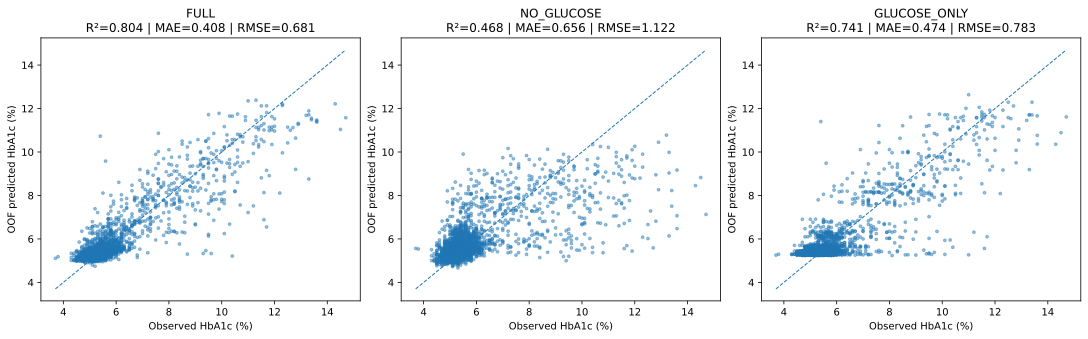

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
observed = np.asarray(y, dtype=float)
plot_min = float(np.nanmin(observed))
plot_max = float(np.nanmax(observed))

for ax, model_name in zip(axes, predictor_sets):
    predicted = cv_results[model_name]["predictions"]
    ax.scatter(observed, predicted, s=8, alpha=0.45)
    ax.plot([plot_min, plot_max], [plot_min, plot_max], linestyle="--", linewidth=1)
    row = cv_results[model_name]["global_metrics"].iloc[0]
    ax.set_title(
        f"{model_name}\n"
        f"R²={row['R2_OOF']:.3f} | MAE={row['MAE_OOF']:.3f} | RMSE={row['RMSE_OOF']:.3f}"
    )
    ax.set_xlabel("Observed HbA1c (%)")
    ax.set_ylabel("OOF predicted HbA1c (%)")

save_figure_bundle(fig, DIRS["figures"] / "S16_model_oof_comparison", dpi=PUBLICATION_DPI)
display(fig)
plt.close(fig)


## 6. Final FULL and NO-GLUCOSE models and complete SHAP matrices

`GLUCOSE-ONLY` is retained as a predictive control. Community reconstruction is performed for `FULL` and `NO-GLUCOSE`, because those are the two multivariable explanatory representations whose community structure is scientifically compared.


In [7]:
from ensanut_hba1c.modeling import fit_final_xgb_and_shap, select_original_shap_matrix

SHAP_MAX_ROWS = None
SHAP_MAX_DISPLAY = 25
NORMALIZED_BEESWARM_TOP_N = 25


def fit_shap_scenario(model_name, X_matrix, output_dir):
    result = fit_final_xgb_and_shap(
        X_matrix,
        y,
        hba1c_cohort_df,
        XGB_PARAMS,
        sample_weights,
        output_dir=output_dir,
        max_rows=SHAP_MAX_ROWS,
        random_state=RANDOM_STATE,
        device=XGB_DEVICE,
        n_jobs=XGB_N_JOBS,
        max_display=SHAP_MAX_DISPLAY,
        normalized_top_n=NORMALIZED_BEESWARM_TOP_N,
    )
    matrix, names, indices, audit = select_original_shap_matrix(
        result["shap_values"], top_n=None
    )
    audit = audit.copy()
    audit.insert(0, "model", model_name)
    return {
        "raw": result,
        "matrix": np.asarray(matrix),
        "feature_names": list(names),
        "feature_indices": indices,
        "audit": audit,
        "source_rows": np.asarray(result["shap_source_rows"]),
        "cohort": result["cohort_shap"].reset_index(drop=True),
    }


if not RUN_FINAL_SHAP:
    raise RuntimeError("RUN_FINAL_SHAP must be True for community reconstruction.")

shap_scenarios = {
    "FULL": fit_shap_scenario("FULL", X_full, DIRS["full"] / "shap"),
    "NO_GLUCOSE": fit_shap_scenario(
        "NO_GLUCOSE", X_no_glucose, DIRS["no_glucose"] / "shap"
    ),
}

if not np.array_equal(
    shap_scenarios["FULL"]["source_rows"],
    shap_scenarios["NO_GLUCOSE"]["source_rows"],
):
    raise AssertionError("FULL and NO-GLUCOSE SHAP participant order differs.")

for model_name, result in shap_scenarios.items():
    np.save(DIRS["full" if model_name == "FULL" else "no_glucose"] / "complete_shap_matrix.npy", result["matrix"])
    result["audit"].to_csv(
        DIRS["full" if model_name == "FULL" else "no_glucose"] / "shap_feature_audit.csv",
        index=False,
    )
    print(f"{model_name}: {result['matrix'].shape[0]:,} participants × {result['matrix'].shape[1]:,} SHAP variables")
    display(result["audit"].sort_values("mean_abs_shap", ascending=False).head(25))


/opt/anaconda3/envs/ensanut/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FULL: 2,530 participants × 1,909 SHAP variables


,model,matrix_column_order,global_importance_rank,feature,mean_abs_shap,selection_mode
18,FULL,19,1,GLU_SUERO,0.736447,all_model_features_in_original_order
3,FULL,4,2,H0303,0.086796,all_model_features_in_original_order
21,FULL,22,3,A0301,0.036084,all_model_features_in_original_order
13,FULL,14,4,ALBU,0.033657,all_model_features_in_original_order
316,FULL,317,5,A0308A,0.031892,all_model_features_in_original_order
19,FULL,20,6,INSULINA,0.026521,all_model_features_in_original_order
282,FULL,283,7,A0303NUM,0.024726,all_model_features_in_original_order
932,FULL,933,8,IMC,0.024151,all_model_features_in_original_order
12,FULL,13,9,AC_URICO,0.017778,all_model_features_in_original_order
931,FULL,932,10,Talla_cm,0.016482,all_model_features_in_original_order


NO_GLUCOSE: 2,530 participants × 1,908 SHAP variables


,model,matrix_column_order,global_importance_rank,feature,mean_abs_shap,selection_mode
281,NO_GLUCOSE,282,1,A0303NUM,0.203382,all_model_features_in_original_order
3,NO_GLUCOSE,4,2,H0303,0.149013,all_model_features_in_original_order
19,NO_GLUCOSE,20,3,TRIG,0.133745,all_model_features_in_original_order
12,NO_GLUCOSE,13,4,AC_URICO,0.126073,all_model_features_in_original_order
20,NO_GLUCOSE,21,5,A0301,0.112694,all_model_features_in_original_order
337,NO_GLUCOSE,338,6,A0316G,0.092520,all_model_features_in_original_order
15,NO_GLUCOSE,16,7,COL_LDL,0.058712,all_model_features_in_original_order
336,NO_GLUCOSE,337,8,A0316F,0.052374,all_model_features_in_original_order
280,NO_GLUCOSE,281,9,A0301A,0.034072,all_model_features_in_original_order
932,NO_GLUCOSE,933,10,Cintura_cm,0.028893,all_model_features_in_original_order


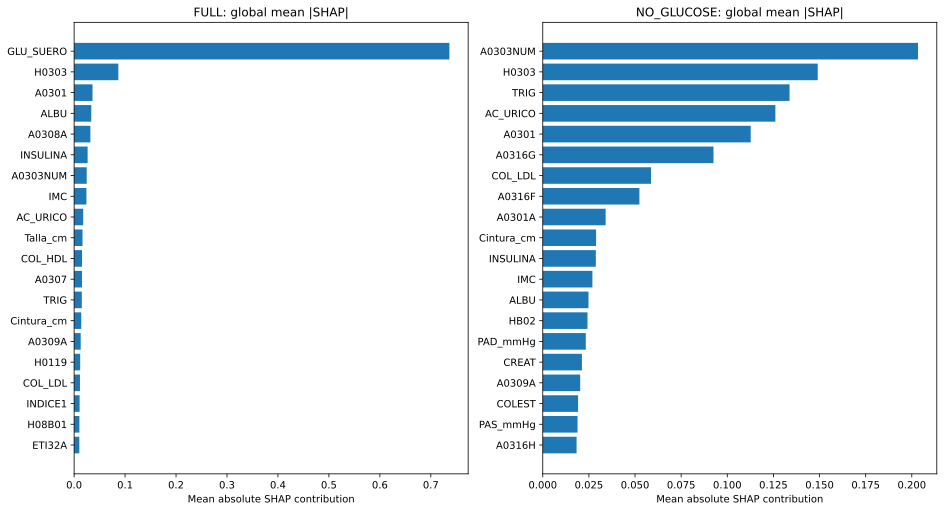

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7), constrained_layout=True)
for ax, model_name in zip(axes, ["FULL", "NO_GLUCOSE"]):
    top = (
        shap_scenarios[model_name]["audit"]
        .sort_values("mean_abs_shap", ascending=False)
        .head(20)
        .sort_values("mean_abs_shap", ascending=True)
    )
    ax.barh(top["feature"], top["mean_abs_shap"])
    ax.set_title(f"{model_name}: global mean |SHAP|")
    ax.set_xlabel("Mean absolute SHAP contribution")

save_figure_bundle(fig, DIRS["figures"] / "S16_global_shap_full_vs_no_glucose", dpi=PUBLICATION_DPI)
display(fig)
plt.close(fig)


## 7. Shared PCA50 → UMAP graph → Leiden configuration


In [9]:
from ensanut_hba1c.config import (
    LeidenConfig,
    PCAConfig,
    PHATEConfig,
    ReductionPipelineConfig,
    UMAPEmbeddingConfig,
    UMAPGraphConfig,
)

PCA_CONFIG = PCAConfig(
    n_components=50,
    whiten=False,
    svd_solver="randomized",
    tol=0.0,
    iterated_power="auto",
    n_oversamples=10,
    power_iteration_normalizer="auto",
    copy=True,
    random_state=RANDOM_STATE,
)

SHARED_UMAP_GRAPH_CONFIG = UMAPGraphConfig(
    n_neighbors=50,
    metric="euclidean",
    metric_kwds=None,
    local_connectivity=10.0,
    set_op_mix_ratio=1.0,
    angular_rp_forest=False,
    force_approximation_algorithm=True,
    unique=False,
    low_memory=True,
    disconnection_distance=None,
    random_state=RANDOM_STATE,
    transform_seed=RANDOM_STATE,
    n_jobs=1,
    verbose=False,
)

UMAP2D_CONFIG = UMAPEmbeddingConfig(
    n_components=2,
    min_dist=1.0,
    spread=1.0,
    learning_rate=1.0,
    init="spectral",
    n_epochs=None,
    repulsion_strength=1.0,
    negative_sample_rate=5,
    output_metric="euclidean",
    output_metric_kwds=None,
    random_state=RANDOM_STATE,
    verbose=False,
)

LEIDEN_CONFIG = LeidenConfig(
    partition_type="RBConfiguration",
    resolution=REFERENCE_RESOLUTION,
    n_iterations=-1,
    max_comm_size=0,
    seed=RANDOM_STATE,
)

PHATE_CONFIG = PHATEConfig(
    n_components=2,
    knn=SHARED_UMAP_GRAPH_CONFIG.n_neighbors,
    decay=40,
    n_landmark=2000,
    t=10,
    gamma=1.0,
    n_pca=None,
    mds_solver="sgd",
    knn_dist="precomputed_affinity",
    knn_max=None,
    mds_dist="euclidean",
    mds="metric",
    n_jobs=1,
    random_state=RANDOM_STATE,
    random_landmarking=False,
    verbose=1,
    t_max=100,
    plot_optimal_t=False,
    graph_kwargs={"thresh": 1e-4},
)

REDUCTION_CONFIG = ReductionPipelineConfig(
    pca=PCA_CONFIG,
    shared_umap_graph=SHARED_UMAP_GRAPH_CONFIG,
    umap2d=UMAP2D_CONFIG,
    leiden=LEIDEN_CONFIG,
    phate=PHATE_CONFIG,
)

display(pd.DataFrame({
    "stage": ["PCA", "Shared UMAP graph", "Leiden", "UMAP2D", "PHATE2D"],
    "main setting": [
        "50 components; no whitening",
        "50 neighbors; Euclidean; local_connectivity=10",
        f"RBConfiguration; resolution={REFERENCE_RESOLUTION}; seed={RANDOM_STATE}",
        "Visualization from the same graph",
        "Precomputed affinity from the same graph",
    ],
}))


,stage,main setting
0,PCA,50 components; no whitening
1,Shared UMAP graph,50 neighbors; Euclidean; local_connectivity=10
2,Leiden,RBConfiguration; resolution=0.7; seed=42
3,UMAP2D,Visualization from the same graph
4,PHATE2D,Precomputed affinity from the same graph


## 8. Reconstruct FULL and NO-GLUCOSE communities


In [10]:
from ensanut_hba1c.reduction_pipeline import run_reduction_and_clustering


def run_community_reconstruction(model_name, shap_matrix, output_dir):
    result = run_reduction_and_clustering(
        shap_matrix,
        REDUCTION_CONFIG,
        output_dir=output_dir,
    )
    table = result["table"].reset_index(drop=True)
    return result, table


if not RUN_CLUSTERING:
    raise RuntimeError("RUN_CLUSTERING must be True for this supplementary notebook.")

full_reduction, full_representation = run_community_reconstruction(
    "FULL", shap_scenarios["FULL"]["matrix"], DIRS["full"] / "reduction"
)
no_glucose_reduction, no_glucose_representation = run_community_reconstruction(
    "NO_GLUCOSE",
    shap_scenarios["NO_GLUCOSE"]["matrix"],
    DIRS["no_glucose"] / "reduction",
)

reconstruction_results = {
    "FULL": (full_reduction, full_representation),
    "NO_GLUCOSE": (no_glucose_reduction, no_glucose_representation),
}

reconstruction_summary_rows = []
for model_name, (result, table) in reconstruction_results.items():
    sizes = table["Cluster_SHAP"].value_counts().sort_index()
    reconstruction_summary_rows.append({
        "model": model_name,
        "participants": len(table),
        "communities": int(sizes.size),
        "minimum_cluster_n": int(sizes.min()),
        "maximum_cluster_n": int(sizes.max()),
        "modularity": float(result["leiden"]["modularity"]),
        "graph_edges": int(result["leiden_graph"]["n_edges"]),
        "graph_fingerprint": result["shared_umap_graph"]["graph_fingerprint"],
    })
    sizes.rename("n").to_csv(
        DIRS["full" if model_name == "FULL" else "no_glucose"] / "cluster_sizes.csv"
    )
    table.to_csv(
        DIRS["full" if model_name == "FULL" else "no_glucose"] / "participant_representation.csv",
        index=False,
    )
    print(f"\n{model_name}")
    display(sizes.rename("n").to_frame())

reconstruction_summary = pd.DataFrame(reconstruction_summary_rows)
reconstruction_summary.to_csv(DIRS["tables"] / "community_reconstruction_summary.csv", index=False)
display(reconstruction_summary)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Running PHATE on precomputed affinity matrix with 2530 observations.
Calculating graph and diffusion operator...
Calculating landmark operator...
  Calculating SVD...
  Calculated SVD in 1.83 seconds.
  Calculating KMeans...
  Calculated KMeans in 1.44 seconds.
Calculated landmark operator in 3.30 seconds.
Calculating diffusion potential...
Calculated diffusion potential in 0.29 seconds.
Calculating metric MDS...
Calculated metric MDS in 1.71 seconds.
Running PHATE on precomputed affinity matrix with 2530 observations.
Calculating graph and diffusion operator...
Calculating landmark operator...
  Calculating SVD...
  Calculated SVD in 0.23 seconds.
  Calculating KMeans...
  Calculated KMeans in 1.14 seconds.
Calculated landmark operator in 1.39 seconds.
Calculating diffusion potential...
Calculated diffusion potential in 0.30 seconds.
Calculating metric MDS...
  SGD-MDS may not have converged: stress changed by 1.1% in final iterations. Consider increasing n_iter or adjusting learning_

,n
Cluster_SHAP,
0,457
1,421
2,361
3,340
4,280
5,265
6,182
7,107
8,99



NO_GLUCOSE


,n
Cluster_SHAP,
0,440
1,414
2,344
3,219
4,210
5,177
6,162
7,152
8,130


,model,participants,communities,minimum_cluster_n,maximum_cluster_n,modularity,graph_edges,graph_fingerprint
0,FULL,2530,10,18,457,0.799441,45358,58483233b5af71e83105c61de3360c508c5180af3840d0...
1,NO_GLUCOSE,2530,12,83,440,0.789442,55718,4e7a566105d25a778391f518d60083de163a3705bc15ce...


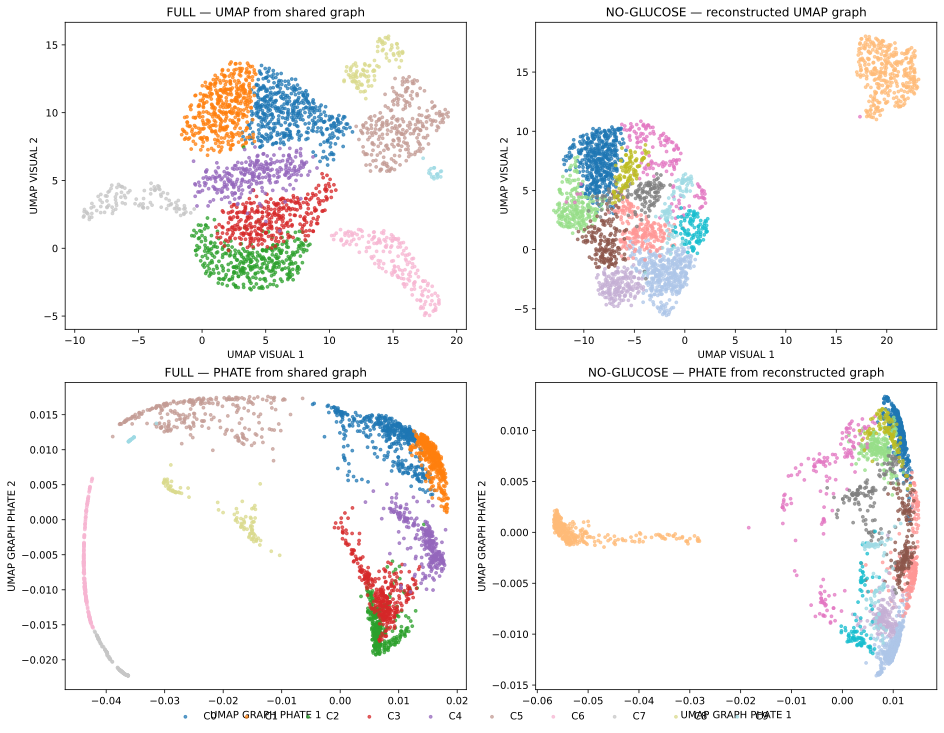

In [11]:
def plot_embedding(ax, table, x_col, y_col, title):
    labels = table["Cluster_SHAP"].to_numpy()
    unique_labels = sorted(np.unique(labels))
    cmap = plt.get_cmap("tab20", max(len(unique_labels), 1))
    for position, label in enumerate(unique_labels):
        mask = labels == label
        ax.scatter(
            table.loc[mask, x_col],
            table.loc[mask, y_col],
            s=8,
            alpha=0.70,
            label=f"C{label}",
            color=cmap(position),
        )
    ax.set_title(title)
    ax.set_xlabel(x_col.replace("_", " "))
    ax.set_ylabel(y_col.replace("_", " "))


fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
plot_embedding(axes[0, 0], full_representation, "UMAP_VISUAL_1", "UMAP_VISUAL_2", "FULL — UMAP from shared graph")
plot_embedding(axes[0, 1], no_glucose_representation, "UMAP_VISUAL_1", "UMAP_VISUAL_2", "NO-GLUCOSE — reconstructed UMAP graph")
plot_embedding(axes[1, 0], full_representation, "UMAP_GRAPH_PHATE_1", "UMAP_GRAPH_PHATE_2", "FULL — PHATE from shared graph")
plot_embedding(axes[1, 1], no_glucose_representation, "UMAP_GRAPH_PHATE_1", "UMAP_GRAPH_PHATE_2", "NO-GLUCOSE — PHATE from reconstructed graph")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.01), ncol=min(10, len(labels)), frameon=False)
save_figure_bundle(fig, DIRS["figures"] / "S15_full_vs_no_glucose_embeddings", dpi=PUBLICATION_DPI)
display(fig)
plt.close(fig)


## 9. Internal clustering metrics


In [12]:
def ordered_pca_columns(table):
    columns = [column for column in table.columns if column.startswith("PCA_")]
    return sorted(columns, key=lambda column: int(column.split("_")[-1]))


def compute_clustering_metrics(model_name, reduction_result, table):
    labels = table["Cluster_SHAP"].to_numpy()
    pca_columns = ordered_pca_columns(table)
    pca_scores = table[pca_columns].to_numpy(dtype=float)
    sizes = pd.Series(labels).value_counts()
    if len(sizes) < 2:
        silhouette = np.nan
        calinski = np.nan
        davies = np.nan
    else:
        silhouette = silhouette_score(pca_scores, labels, metric="euclidean")
        calinski = calinski_harabasz_score(pca_scores, labels)
        davies = davies_bouldin_score(pca_scores, labels)
    return {
        "model": model_name,
        "participants": len(labels),
        "pca_dimensions": len(pca_columns),
        "communities": int(len(sizes)),
        "modularity": float(reduction_result["leiden"]["modularity"]),
        "silhouette_PCA50": float(silhouette),
        "calinski_harabasz_PCA50": float(calinski),
        "davies_bouldin_PCA50": float(davies),
        "minimum_cluster_n": int(sizes.min()),
        "maximum_cluster_n": int(sizes.max()),
    }


clustering_metrics = pd.DataFrame([
    compute_clustering_metrics("FULL", full_reduction, full_representation),
    compute_clustering_metrics(
        "NO_GLUCOSE", no_glucose_reduction, no_glucose_representation
    ),
])
clustering_metrics.to_csv(DIRS["tables"] / "clustering_metrics.csv", index=False)
display(clustering_metrics)


,model,participants,pca_dimensions,communities,modularity,silhouette_PCA50,calinski_harabasz_PCA50,davies_bouldin_PCA50,minimum_cluster_n,maximum_cluster_n
0,FULL,2530,50,10,0.799441,0.229935,5178.602202,1.262108,18,457
1,NO_GLUCOSE,2530,50,12,0.789442,0.146171,393.580752,1.721537,83,440


## 10. Twenty Leiden initializations on the fixed FULL graph

This analysis changes **only the Leiden initialization seed**. PCA50 and the UMAP fuzzy graph remain fixed. It therefore quantifies optimizer/partition stability on the exact graph used for C0–C9; it is not described as 20 complete reconstructions of XGBoost, SHAP, PCA, and UMAP.


In [13]:
import igraph as ig
import leidenalg


def sparse_graph_to_igraph(adjacency):
    adjacency = sparse.csr_matrix(adjacency)
    upper = sparse.triu(adjacency, k=1).tocoo()
    graph = ig.Graph(
        n=adjacency.shape[0],
        edges=list(zip(upper.row.tolist(), upper.col.tolist())),
        directed=False,
    )
    graph.es["weight"] = upper.data.astype(float).tolist()
    return graph


def run_leiden_fixed_graph(graph, resolution, seed):
    partition_name = str(LEIDEN_CONFIG.partition_type).lower()
    common = {
        "weights": "weight",
        "n_iterations": int(LEIDEN_CONFIG.n_iterations),
        "seed": int(seed),
        "max_comm_size": int(LEIDEN_CONFIG.max_comm_size),
    }
    if partition_name in {"rbconfiguration", "rb_configuration", "rb"}:
        partition = leidenalg.find_partition(
            graph,
            leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=float(resolution),
            **common,
        )
    elif partition_name == "cpm":
        partition = leidenalg.find_partition(
            graph,
            leidenalg.CPMVertexPartition,
            resolution_parameter=float(resolution),
            **common,
        )
    elif partition_name == "modularity":
        partition = leidenalg.find_partition(
            graph,
            leidenalg.ModularityVertexPartition,
            **common,
        )
    else:
        raise ValueError(f"Unsupported Leiden partition type: {LEIDEN_CONFIG.partition_type}")

    labels = np.asarray(partition.membership, dtype=int)
    modularity = float(graph.modularity(labels.tolist(), weights="weight"))
    return labels, modularity, float(partition.quality())


def pairwise_partition_matrices(label_vectors, names):
    n = len(label_vectors)
    ari = np.eye(n, dtype=float)
    nmi = np.eye(n, dtype=float)
    for i, j in combinations(range(n), 2):
        ari_value = adjusted_rand_score(label_vectors[i], label_vectors[j])
        nmi_value = normalized_mutual_info_score(label_vectors[i], label_vectors[j])
        ari[i, j] = ari[j, i] = ari_value
        nmi[i, j] = nmi[j, i] = nmi_value
    return (
        pd.DataFrame(ari, index=names, columns=names),
        pd.DataFrame(nmi, index=names, columns=names),
    )


def align_many_to_one(reference, candidate):
    """Map each candidate cluster to the reference cluster with maximum overlap."""
    reference = np.asarray(reference)
    candidate = np.asarray(candidate)
    mapping = {}
    for candidate_label in np.unique(candidate):
        mask = candidate == candidate_label
        overlaps = pd.Series(reference[mask]).value_counts()
        mapping[int(candidate_label)] = int(overlaps.index[0])
    return np.asarray([mapping[int(label)] for label in candidate], dtype=int), mapping


def best_overlap_for_reference_cluster(reference, candidate, reference_label):
    reference_mask = reference == reference_label
    best = {"jaccard": 0.0, "retention": 0.0, "purity": 0.0, "matched_cluster": None}
    for candidate_label in np.unique(candidate):
        candidate_mask = candidate == candidate_label
        intersection = int(np.sum(reference_mask & candidate_mask))
        union = int(np.sum(reference_mask | candidate_mask))
        if intersection == 0:
            continue
        current = {
            "jaccard": intersection / union,
            "retention": intersection / int(reference_mask.sum()),
            "purity": intersection / int(candidate_mask.sum()),
            "matched_cluster": int(candidate_label),
        }
        if current["jaccard"] > best["jaccard"]:
            best = current
    return best


full_graph_sparse = full_reduction["shared_umap_graph"]["graph"]
full_igraph = sparse_graph_to_igraph(full_graph_sparse)
reference_labels = full_representation["Cluster_SHAP"].to_numpy(dtype=int)

stability_label_vectors = []
stability_run_rows = []
for seed in LEIDEN_SEEDS:
    labels, modularity, quality = run_leiden_fixed_graph(
        full_igraph, REFERENCE_RESOLUTION, seed
    )
    stability_label_vectors.append(labels)
    stability_run_rows.append({
        "seed": seed,
        "communities": int(np.unique(labels).size),
        "modularity": modularity,
        "partition_quality": quality,
        "ARI_vs_reported_reference": adjusted_rand_score(reference_labels, labels),
        "NMI_vs_reported_reference": normalized_mutual_info_score(reference_labels, labels),
    })

stability_run_metrics = pd.DataFrame(stability_run_rows)
seed_names = [f"seed_{seed}" for seed in LEIDEN_SEEDS]
ari_matrix, nmi_matrix = pairwise_partition_matrices(stability_label_vectors, seed_names)

label_table = pd.DataFrame({
    "participant_row": np.arange(len(reference_labels)),
    "reported_reference": reference_labels,
})
for seed, labels in zip(LEIDEN_SEEDS, stability_label_vectors):
    label_table[f"seed_{seed}"] = labels

stability_run_metrics.to_csv(DIRS["stability"] / "run_metrics.csv", index=False)
ari_matrix.to_csv(DIRS["stability"] / "pairwise_ARI_matrix.csv")
nmi_matrix.to_csv(DIRS["stability"] / "pairwise_NMI_matrix.csv")
label_table.to_csv(DIRS["stability"] / "participant_labels_all_runs.csv", index=False)

display(Markdown("### Run-level stability metrics"))
display(stability_run_metrics)


### Run-level stability metrics

,seed,communities,modularity,partition_quality,ARI_vs_reported_reference,NMI_vs_reported_reference
0,42,10,0.799441,31516.293118,1.000000,1.000000
1,7,10,0.799728,31527.433614,0.902079,0.931524
2,13,10,0.795927,31419.676171,0.791298,0.884891
3,19,11,0.794473,31361.362349,0.799360,0.903612
4,23,11,0.790931,31394.772213,0.775288,0.869011
5,29,12,0.802550,31483.549171,0.829911,0.880097
6,31,10,0.799280,31509.708390,0.926387,0.949863
7,37,11,0.797382,31422.915040,0.884354,0.916060
8,43,10,0.800119,31542.518817,0.917250,0.943580
9,47,11,0.803431,31563.693848,0.862504,0.912610


In [14]:
# Cluster-level stability against the reported C0–C9 partition.
cluster_stability_rows = []
for reference_cluster in sorted(np.unique(reference_labels)):
    for seed, candidate_labels in zip(LEIDEN_SEEDS, stability_label_vectors):
        if seed == RANDOM_STATE:
            continue
        overlap = best_overlap_for_reference_cluster(
            reference_labels, candidate_labels, reference_cluster
        )
        cluster_stability_rows.append({
            "reference_cluster": int(reference_cluster),
            "seed": int(seed),
            **overlap,
        })

cluster_stability_long = pd.DataFrame(cluster_stability_rows)
cluster_stability_summary = (
    cluster_stability_long
    .groupby("reference_cluster", as_index=False)
    .agg(
        mean_best_jaccard=("jaccard", "mean"),
        minimum_best_jaccard=("jaccard", "min"),
        mean_retention=("retention", "mean"),
        minimum_retention=("retention", "min"),
        mean_purity=("purity", "mean"),
    )
)
cluster_sizes_reference = pd.Series(reference_labels).value_counts().sort_index()
cluster_stability_summary.insert(
    1,
    "reference_n",
    cluster_stability_summary["reference_cluster"].map(cluster_sizes_reference).astype(int),
)

# Participant-level retention after mapping each run to its dominant reference overlap.
aligned_runs = []
for labels in stability_label_vectors:
    aligned, _ = align_many_to_one(reference_labels, labels)
    aligned_runs.append(aligned)
aligned_runs = np.column_stack(aligned_runs)
participant_reference_retention = np.mean(aligned_runs == reference_labels[:, None], axis=1)
participant_consensus = np.asarray([
    Counter(row.tolist()).most_common(1)[0][0] for row in aligned_runs
], dtype=int)
participant_consensus_confidence = np.asarray([
    Counter(row.tolist()).most_common(1)[0][1] / aligned_runs.shape[1]
    for row in aligned_runs
], dtype=float)

participant_stability = pd.DataFrame({
    "participant_row": np.arange(len(reference_labels)),
    "reference_cluster": reference_labels,
    "consensus_cluster": participant_consensus,
    "reference_retention": participant_reference_retention,
    "consensus_confidence": participant_consensus_confidence,
})
for id_column in ID_COLUMNS:
    if id_column in shap_scenarios["FULL"]["cohort"]:
        participant_stability.insert(
            1,
            id_column,
            shap_scenarios["FULL"]["cohort"][id_column].to_numpy(),
        )

cluster_stability_long.to_csv(DIRS["stability"] / "cluster_stability_by_run.csv", index=False)
cluster_stability_summary.to_csv(DIRS["stability"] / "cluster_stability_summary.csv", index=False)
participant_stability.to_csv(DIRS["stability"] / "participant_stability.csv", index=False)

display(Markdown("### Stability of each reported community"))
display(cluster_stability_summary)
display(Markdown("### Participant-level stability summary"))
display(participant_stability[["reference_retention", "consensus_confidence"]].describe())


### Stability of each reported community

,reference_cluster,reference_n,mean_best_jaccard,minimum_best_jaccard,mean_retention,minimum_retention,mean_purity
0,0,457,0.795312,0.601818,0.824830,0.617068,0.957740
1,1,421,0.837953,0.702838,0.948744,0.783848,0.882789
2,2,361,0.855162,0.576159,0.930456,0.720222,0.914319
3,3,340,0.822306,0.343434,0.873065,0.458824,0.924621
4,4,280,0.972309,0.893548,0.987594,0.967857,0.984387
5,5,265,0.999404,0.996226,0.999404,0.996226,1.000000
6,6,182,0.927575,0.777778,0.939271,0.835165,0.988304
7,7,107,0.795376,0.514019,0.795376,0.514019,1.000000
8,8,99,1.000000,1.000000,1.000000,1.000000,1.000000
9,9,18,1.000000,1.000000,1.000000,1.000000,1.000000


### Participant-level stability summary

,reference_retention,consensus_confidence
count,2530.000000,2530.000000
mean,0.939921,0.956917
std,0.148197,0.081161
min,0.050000,0.500000
25%,0.950000,0.950000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


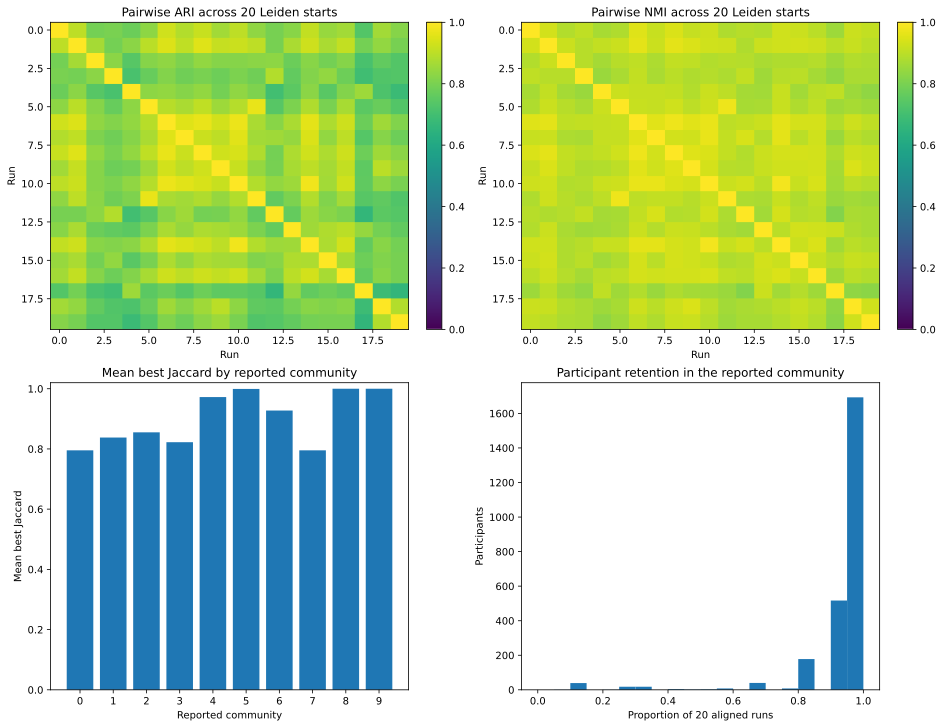

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

im0 = axes[0, 0].imshow(ari_matrix.to_numpy(), vmin=0, vmax=1, aspect="auto")
axes[0, 0].set_title("Pairwise ARI across 20 Leiden starts")
axes[0, 0].set_xlabel("Run")
axes[0, 0].set_ylabel("Run")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(nmi_matrix.to_numpy(), vmin=0, vmax=1, aspect="auto")
axes[0, 1].set_title("Pairwise NMI across 20 Leiden starts")
axes[0, 1].set_xlabel("Run")
axes[0, 1].set_ylabel("Run")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046)

axes[1, 0].bar(
    cluster_stability_summary["reference_cluster"].astype(str),
    cluster_stability_summary["mean_best_jaccard"],
)
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].set_title("Mean best Jaccard by reported community")
axes[1, 0].set_xlabel("Reported community")
axes[1, 0].set_ylabel("Mean best Jaccard")

axes[1, 1].hist(participant_reference_retention, bins=np.linspace(0, 1, 21))
axes[1, 1].set_title("Participant retention in the reported community")
axes[1, 1].set_xlabel("Proportion of 20 aligned runs")
axes[1, 1].set_ylabel("Participants")

save_figure_bundle(fig, DIRS["figures"] / "S13_leiden_fixed_graph_stability", dpi=PUBLICATION_DPI)
display(fig)
plt.close(fig)


## 11. Compact resolution analysis on the fixed FULL graph

For each resolution, Leiden is run with five seeds. Graph geometry is unchanged. The table reports the number of communities, modularity, between-seed ARI, cluster-size behavior, and secondary Euclidean diagnostics calculated in PCA50. These metrics support a transparent justification of the ten-community reference solution without claiming that one metric alone defines the true number of communities.


In [16]:
def safe_mean_pairwise_ari(label_vectors):
    values = [
        adjusted_rand_score(label_vectors[i], label_vectors[j])
        for i, j in combinations(range(len(label_vectors)), 2)
    ]
    return float(np.mean(values)), float(np.std(values, ddof=1)) if len(values) > 1 else 0.0


if not RUN_RESOLUTION_SCAN:
    raise RuntimeError("RUN_RESOLUTION_SCAN must be True for resolution justification.")

full_pca_columns = ordered_pca_columns(full_representation)
full_pca_scores = full_representation[full_pca_columns].to_numpy(dtype=float)
resolution_run_rows = []
resolution_summary_rows = []

for resolution in RESOLUTION_GRID:
    label_vectors = []
    modularities = []
    qualities = []
    for seed in RESOLUTION_SEEDS:
        labels, modularity, quality = run_leiden_fixed_graph(
            full_igraph, resolution, seed
        )
        label_vectors.append(labels)
        modularities.append(modularity)
        qualities.append(quality)
        sizes = pd.Series(labels).value_counts()
        resolution_run_rows.append({
            "resolution": resolution,
            "seed": seed,
            "communities": int(sizes.size),
            "modularity": modularity,
            "partition_quality": quality,
            "minimum_cluster_n": int(sizes.min()),
            "maximum_cluster_n": int(sizes.max()),
            "ARI_vs_reported_reference": adjusted_rand_score(reference_labels, labels),
            "NMI_vs_reported_reference": normalized_mutual_info_score(reference_labels, labels),
        })

    pairwise_ari_mean, pairwise_ari_sd = safe_mean_pairwise_ari(label_vectors)
    seed42_labels = label_vectors[RESOLUTION_SEEDS.index(RANDOM_STATE)]
    seed42_sizes = pd.Series(seed42_labels).value_counts()
    micro_threshold = max(10, int(np.ceil(0.01 * len(seed42_labels))))
    microcluster_fraction = float(
        seed42_sizes[seed42_sizes < micro_threshold].sum() / len(seed42_labels)
    )

    resolution_summary_rows.append({
        "resolution": resolution,
        "communities_seed42": int(seed42_sizes.size),
        "communities_min": int(min(np.unique(labels).size for labels in label_vectors)),
        "communities_max": int(max(np.unique(labels).size for labels in label_vectors)),
        "modularity_mean": float(np.mean(modularities)),
        "modularity_sd": float(np.std(modularities, ddof=1)),
        "pairwise_ARI_mean": pairwise_ari_mean,
        "pairwise_ARI_sd": pairwise_ari_sd,
        "ARI_vs_reported_reference_seed42": adjusted_rand_score(reference_labels, seed42_labels),
        "minimum_cluster_n_seed42": int(seed42_sizes.min()),
        "microcluster_fraction_seed42": microcluster_fraction,
        "silhouette_PCA50_seed42": silhouette_score(full_pca_scores, seed42_labels),
        "calinski_harabasz_PCA50_seed42": calinski_harabasz_score(full_pca_scores, seed42_labels),
        "davies_bouldin_PCA50_seed42": davies_bouldin_score(full_pca_scores, seed42_labels),
    })

resolution_run_metrics = pd.DataFrame(resolution_run_rows)
resolution_summary = pd.DataFrame(resolution_summary_rows)
resolution_run_metrics.to_csv(DIRS["resolution"] / "resolution_run_metrics.csv", index=False)
resolution_summary.to_csv(DIRS["resolution"] / "resolution_summary.csv", index=False)

display(resolution_summary)


,resolution,communities_seed42,communities_min,communities_max,modularity_mean,modularity_sd,pairwise_ARI_mean,pairwise_ARI_sd,ARI_vs_reported_reference_seed42,minimum_cluster_n_seed42,microcluster_fraction_seed42,silhouette_PCA50_seed42,calinski_harabasz_PCA50_seed42,davies_bouldin_PCA50_seed42
0,0.4,8,8,9,0.758664,0.017111,0.869247,0.071183,0.649156,18,0.007115,0.239144,4497.366812,1.132137
1,0.5,9,9,9,0.774055,0.009456,0.868964,0.052131,0.728701,18,0.007115,0.249885,5782.791592,1.175536
2,0.6,11,9,11,0.790928,0.010679,0.773950,0.069684,0.845520,18,0.007115,0.205646,4700.988427,1.274545
3,0.7,10,10,11,0.798046,0.002214,0.861158,0.053420,1.000000,18,0.007115,0.229935,5178.602202,1.262108
4,0.8,11,11,14,0.801264,0.004540,0.764678,0.077857,0.898880,18,0.007115,0.201514,4699.134665,1.296627
5,0.9,13,13,14,0.803047,0.002126,0.793473,0.050687,0.872710,18,0.007115,0.147724,5470.294013,1.445196
6,1.0,15,12,16,0.804035,0.001506,0.806839,0.046148,0.769839,18,0.007115,0.138966,4878.262603,1.556074


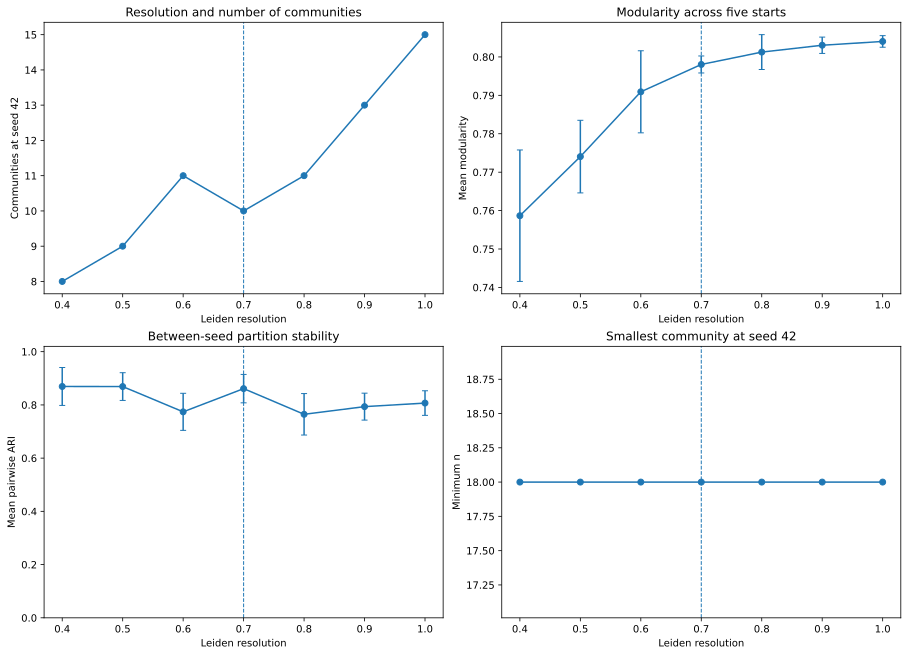

**Reference resolution summary.** At resolution 0.70, seed 42 produced **10 communities**, mean modularity across five starts was **0.798**, mean pairwise ARI was **0.861**, and the smallest seed-42 community contained **18 participants**.

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 9), constrained_layout=True)

axes[0, 0].plot(
    resolution_summary["resolution"],
    resolution_summary["communities_seed42"],
    marker="o",
)
axes[0, 0].axvline(REFERENCE_RESOLUTION, linestyle="--", linewidth=1)
axes[0, 0].set_title("Resolution and number of communities")
axes[0, 0].set_xlabel("Leiden resolution")
axes[0, 0].set_ylabel("Communities at seed 42")

axes[0, 1].errorbar(
    resolution_summary["resolution"],
    resolution_summary["modularity_mean"],
    yerr=resolution_summary["modularity_sd"],
    marker="o",
    capsize=3,
)
axes[0, 1].axvline(REFERENCE_RESOLUTION, linestyle="--", linewidth=1)
axes[0, 1].set_title("Modularity across five starts")
axes[0, 1].set_xlabel("Leiden resolution")
axes[0, 1].set_ylabel("Mean modularity")

axes[1, 0].errorbar(
    resolution_summary["resolution"],
    resolution_summary["pairwise_ARI_mean"],
    yerr=resolution_summary["pairwise_ARI_sd"],
    marker="o",
    capsize=3,
)
axes[1, 0].axvline(REFERENCE_RESOLUTION, linestyle="--", linewidth=1)
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].set_title("Between-seed partition stability")
axes[1, 0].set_xlabel("Leiden resolution")
axes[1, 0].set_ylabel("Mean pairwise ARI")

axes[1, 1].plot(
    resolution_summary["resolution"],
    resolution_summary["minimum_cluster_n_seed42"],
    marker="o",
)
axes[1, 1].axvline(REFERENCE_RESOLUTION, linestyle="--", linewidth=1)
axes[1, 1].set_title("Smallest community at seed 42")
axes[1, 1].set_xlabel("Leiden resolution")
axes[1, 1].set_ylabel("Minimum n")

save_figure_bundle(fig, DIRS["figures"] / "S14_resolution_analysis", dpi=PUBLICATION_DPI)
display(fig)
plt.close(fig)

reference_resolution_row = resolution_summary.loc[
    np.isclose(resolution_summary["resolution"], REFERENCE_RESOLUTION)
].iloc[0]
display(Markdown(
    f"**Reference resolution summary.** At resolution {REFERENCE_RESOLUTION:.2f}, "
    f"seed 42 produced **{int(reference_resolution_row['communities_seed42'])} communities**, "
    f"mean modularity across five starts was **{reference_resolution_row['modularity_mean']:.3f}**, "
    f"mean pairwise ARI was **{reference_resolution_row['pairwise_ARI_mean']:.3f}**, "
    f"and the smallest seed-42 community contained **{int(reference_resolution_row['minimum_cluster_n_seed42'])} participants**."
))


## 12. FULL versus NO-GLUCOSE partition comparison


In [18]:
full_labels = full_representation["Cluster_SHAP"].to_numpy(dtype=int)
no_glucose_labels = no_glucose_representation["Cluster_SHAP"].to_numpy(dtype=int)

partition_comparison = pd.DataFrame([{
    "comparison": "FULL vs NO_GLUCOSE",
    "adjusted_rand_index": adjusted_rand_score(full_labels, no_glucose_labels),
    "adjusted_mutual_information": adjusted_mutual_info_score(full_labels, no_glucose_labels),
    "normalized_mutual_information": normalized_mutual_info_score(full_labels, no_glucose_labels),
    "v_measure": v_measure_score(full_labels, no_glucose_labels),
    "fowlkes_mallows": fowlkes_mallows_score(full_labels, no_glucose_labels),
    "FULL_communities": int(np.unique(full_labels).size),
    "NO_GLUCOSE_communities": int(np.unique(no_glucose_labels).size),
}])

overlap_table = pd.crosstab(
    pd.Series(full_labels, name="FULL"),
    pd.Series(no_glucose_labels, name="NO_GLUCOSE"),
)
row_normalized_overlap = overlap_table.div(overlap_table.sum(axis=1), axis=0)

partition_comparison.to_csv(DIRS["comparison"] / "global_partition_metrics.csv", index=False)
overlap_table.to_csv(DIRS["comparison"] / "participant_overlap_counts.csv")
row_normalized_overlap.to_csv(DIRS["comparison"] / "participant_overlap_row_proportions.csv")

display(partition_comparison)
display(Markdown("### Participant overlap counts"))
display(overlap_table)
display(Markdown("### Row-normalized overlap: destination distribution of each FULL community"))
display(row_normalized_overlap.round(3))


,comparison,adjusted_rand_index,adjusted_mutual_information,normalized_mutual_information,v_measure,fowlkes_mallows,FULL_communities,NO_GLUCOSE_communities
0,FULL vs NO_GLUCOSE,0.233751,0.3589,0.364703,0.364703,0.325925,10,12


### Participant overlap counts

NO_GLUCOSE,0,1,2,3,4,5,6,7,8,9,10,11
FULL,,,,,,,,,,,,
0,158,0,0,109,30,0,46,17,48,37,0,12
1,219,0,0,49,24,0,11,50,27,35,1,5
2,0,209,1,0,3,55,3,22,4,0,54,10
3,0,173,2,0,7,98,15,6,8,0,11,20
4,1,15,0,0,127,6,63,13,14,0,27,14
5,55,15,56,36,15,14,20,13,13,17,2,9
6,7,0,122,17,0,1,2,8,8,9,1,7
7,0,1,66,4,0,1,0,21,6,3,0,5
8,0,0,97,1,0,0,0,1,0,0,0,0


### Row-normalized overlap: destination distribution of each FULL community

NO_GLUCOSE,0,1,2,3,4,5,6,7,8,9,10,11
FULL,,,,,,,,,,,,
0,0.346,0.000,0.000,0.239,0.066,0.000,0.101,0.037,0.105,0.081,0.000,0.026
1,0.520,0.000,0.000,0.116,0.057,0.000,0.026,0.119,0.064,0.083,0.002,0.012
2,0.000,0.579,0.003,0.000,0.008,0.152,0.008,0.061,0.011,0.000,0.150,0.028
3,0.000,0.509,0.006,0.000,0.021,0.288,0.044,0.018,0.024,0.000,0.032,0.059
4,0.004,0.054,0.000,0.000,0.454,0.021,0.225,0.046,0.050,0.000,0.096,0.050
5,0.208,0.057,0.211,0.136,0.057,0.053,0.075,0.049,0.049,0.064,0.008,0.034
6,0.038,0.000,0.670,0.093,0.000,0.005,0.011,0.044,0.044,0.049,0.005,0.038
7,0.000,0.009,0.617,0.037,0.000,0.009,0.000,0.196,0.056,0.028,0.000,0.047
8,0.000,0.000,0.980,0.010,0.000,0.000,0.000,0.010,0.000,0.000,0.000,0.000


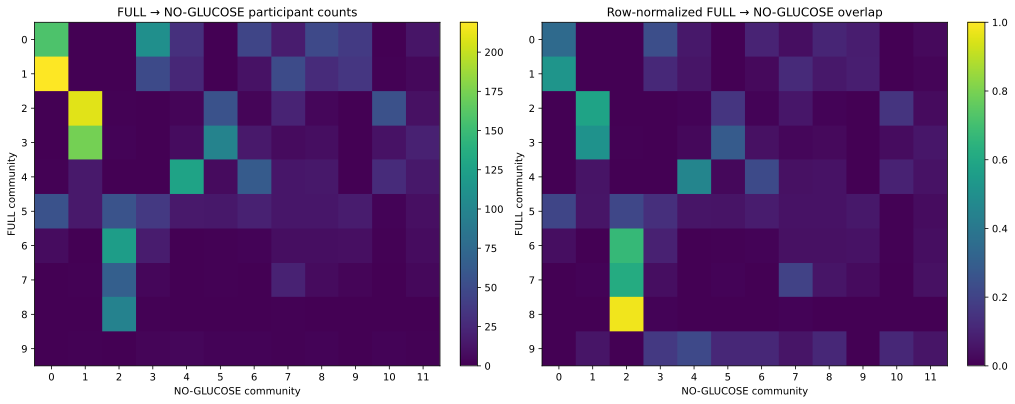

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

im0 = axes[0].imshow(overlap_table.to_numpy(), aspect="auto")
axes[0].set_title("FULL → NO-GLUCOSE participant counts")
axes[0].set_xlabel("NO-GLUCOSE community")
axes[0].set_ylabel("FULL community")
axes[0].set_xticks(range(overlap_table.shape[1]), overlap_table.columns)
axes[0].set_yticks(range(overlap_table.shape[0]), overlap_table.index)
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(row_normalized_overlap.to_numpy(), vmin=0, vmax=1, aspect="auto")
axes[1].set_title("Row-normalized FULL → NO-GLUCOSE overlap")
axes[1].set_xlabel("NO-GLUCOSE community")
axes[1].set_ylabel("FULL community")
axes[1].set_xticks(range(row_normalized_overlap.shape[1]), row_normalized_overlap.columns)
axes[1].set_yticks(range(row_normalized_overlap.shape[0]), row_normalized_overlap.index)
fig.colorbar(im1, ax=axes[1], fraction=0.046)

save_figure_bundle(fig, DIRS["figures"] / "S15_partition_overlap_heatmaps", dpi=PUBLICATION_DPI)
display(fig)
plt.close(fig)


## 13. Interactive Sankey: FULL communities → NO-GLUCOSE communities


Static Sankey export skipped; interactive HTML was saved. Reason: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



,FULL_cluster,NO_GLUCOSE_cluster,n,percentage_of_FULL_cluster
0,0,3,109,23.851204
1,0,8,48,10.503282
2,0,9,37,8.096280
3,0,0,158,34.573304
4,0,7,17,3.719912
...,...,...,...,...
81,9,10,2,11.111111
82,9,5,2,11.111111
83,9,11,1,5.555556
84,9,4,4,22.222222


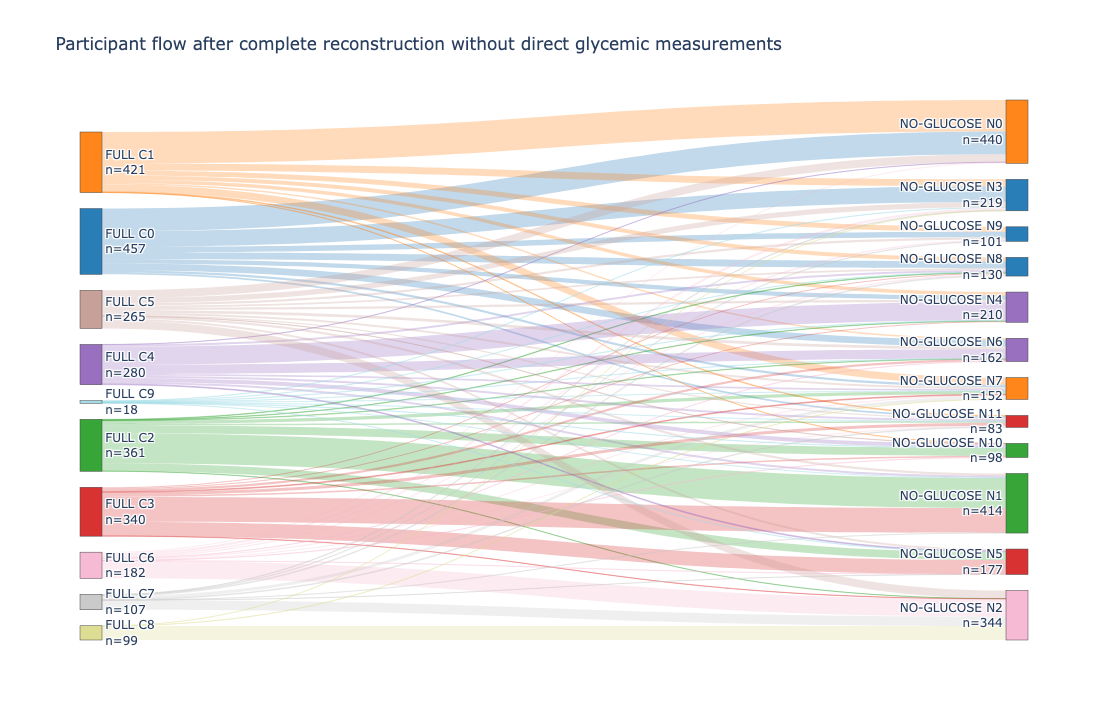

In [20]:
import plotly.graph_objects as go


def rgba_string(rgba, alpha=None):
    r, g, b, a = rgba
    if alpha is not None:
        a = alpha
    return f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{a:.3f})"


full_clusters = list(overlap_table.index)
no_glucose_clusters = list(overlap_table.columns)

# Order NO-GLUCOSE nodes by the FULL cluster receiving their largest overlap.
no_glucose_order = sorted(
    no_glucose_clusters,
    key=lambda cluster: (
        int(overlap_table[cluster].idxmax()),
        -int(overlap_table[cluster].max()),
        int(cluster),
    ),
)

full_sizes = overlap_table.sum(axis=1)
no_glucose_sizes = overlap_table.sum(axis=0)
node_labels = [
    f"FULL C{cluster}<br>n={int(full_sizes.loc[cluster]):,}"
    for cluster in full_clusters
] + [
    f"NO-GLUCOSE N{cluster}<br>n={int(no_glucose_sizes.loc[cluster]):,}"
    for cluster in no_glucose_order
]

full_node_index = {cluster: position for position, cluster in enumerate(full_clusters)}
no_glucose_node_index = {
    cluster: len(full_clusters) + position
    for position, cluster in enumerate(no_glucose_order)
}

cmap = plt.get_cmap("tab20", max(len(full_clusters), 1))
full_colors = {
    cluster: rgba_string(cmap(position), alpha=0.95)
    for position, cluster in enumerate(full_clusters)
}
node_colors = [full_colors[cluster] for cluster in full_clusters]
for cluster in no_glucose_order:
    dominant_full = int(overlap_table[cluster].idxmax())
    node_colors.append(full_colors[dominant_full])

sources, targets, values, link_colors, customdata = [], [], [], [], []
flow_rows = []
for full_cluster in full_clusters:
    for no_glucose_cluster in no_glucose_order:
        value = int(overlap_table.loc[full_cluster, no_glucose_cluster])
        if value == 0:
            continue
        source_total = int(full_sizes.loc[full_cluster])
        sources.append(full_node_index[full_cluster])
        targets.append(no_glucose_node_index[no_glucose_cluster])
        values.append(value)
        link_colors.append(full_colors[full_cluster].replace("0.950", "0.280"))
        customdata.append([full_cluster, no_glucose_cluster, value / source_total])
        flow_rows.append({
            "FULL_cluster": int(full_cluster),
            "NO_GLUCOSE_cluster": int(no_glucose_cluster),
            "n": value,
            "percentage_of_FULL_cluster": 100 * value / source_total,
        })

sankey_figure = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=16,
        thickness=22,
        line=dict(width=0.5),
        label=node_labels,
        color=node_colors,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
        customdata=customdata,
        hovertemplate=(
            "FULL C%{customdata[0]} → NO-GLUCOSE N%{customdata[1]}<br>"
            "n=%{value:,}<br>% of FULL community=%{customdata[2]:.1%}<extra></extra>"
        ),
    ),
))
sankey_figure.update_layout(
    title="Participant flow after complete reconstruction without direct glycemic measurements",
    font_size=12,
    width=1200,
    height=720,
)

sankey_flows = pd.DataFrame(flow_rows)
sankey_flows.to_csv(DIRS["comparison"] / "sankey_flows.csv", index=False)
sankey_figure.write_html(DIRS["comparison"] / "FULL_to_NO_GLUCOSE_sankey.html")
try:
    sankey_figure.write_image(DIRS["comparison"] / "FULL_to_NO_GLUCOSE_sankey.png", scale=3)
    sankey_figure.write_image(DIRS["comparison"] / "FULL_to_NO_GLUCOSE_sankey.svg")
except Exception as error:
    print("Static Sankey export skipped; interactive HTML was saved. Reason:", error)

display(sankey_flows)
display(sankey_figure)


## 14. Supplementary summary tables and manuscript-ready interpretation


In [21]:
# Compact model table with the metrics used in the manuscript.
model_table_columns = [
    column for column in [
        "model", "R2_OOF", "MAE_OOF", "RMSE_OOF", "Spearman_OOF", "n"
    ]
    if column in global_metrics_all.columns
]
model_manuscript_table = global_metrics_all[model_table_columns].copy()
model_manuscript_table.to_csv(
    DIRS["tables"] / "Table_S_model_comparison.csv", index=False
)

stability_off_diagonal_ari = ari_matrix.to_numpy()[np.triu_indices_from(ari_matrix, k=1)]
stability_off_diagonal_nmi = nmi_matrix.to_numpy()[np.triu_indices_from(nmi_matrix, k=1)]

stability_manuscript_table = pd.DataFrame([{
    "Leiden_runs": len(LEIDEN_SEEDS),
    "fixed_graph": True,
    "reference_seed": RANDOM_STATE,
    "resolution": REFERENCE_RESOLUTION,
    "pairwise_ARI_mean": float(np.mean(stability_off_diagonal_ari)),
    "pairwise_ARI_min": float(np.min(stability_off_diagonal_ari)),
    "pairwise_NMI_mean": float(np.mean(stability_off_diagonal_nmi)),
    "pairwise_NMI_min": float(np.min(stability_off_diagonal_nmi)),
    "participant_reference_retention_mean": float(np.mean(participant_reference_retention)),
    "participant_reference_retention_median": float(np.median(participant_reference_retention)),
}])
stability_manuscript_table.to_csv(
    DIRS["tables"] / "Table_S_leiden_stability.csv", index=False
)
cluster_stability_summary.to_csv(
    DIRS["tables"] / "Table_S_cluster_specific_stability.csv", index=False
)
resolution_summary.to_csv(
    DIRS["tables"] / "Table_S_resolution_analysis.csv", index=False
)
partition_comparison.to_csv(
    DIRS["tables"] / "Table_S_full_vs_no_glucose_partition.csv", index=False
)

print("MODEL COMPARISON")
display(model_manuscript_table)
print("LEIDEN FIXED-GRAPH STABILITY")
display(stability_manuscript_table)
print("CLUSTER-SPECIFIC STABILITY")
display(cluster_stability_summary)
print("FULL VS NO-GLUCOSE PARTITION")
display(partition_comparison)


MODEL COMPARISON


,model,R2_OOF,MAE_OOF,RMSE_OOF,Spearman_OOF,n
0,FULL,0.804263,0.408325,0.680907,0.734471,2530
1,NO_GLUCOSE,0.468141,0.656019,1.122405,0.609060,2530
2,GLUCOSE_ONLY,0.741234,0.473633,0.782897,0.566437,2530


LEIDEN FIXED-GRAPH STABILITY


,Leiden_runs,fixed_graph,reference_seed,resolution,pairwise_ARI_mean,pairwise_ARI_min,pairwise_NMI_mean,pairwise_NMI_min,participant_reference_retention_mean,participant_reference_retention_median
0,20,True,42,0.7,0.831927,0.659599,0.901882,0.814884,0.939921,1.0


CLUSTER-SPECIFIC STABILITY


,reference_cluster,reference_n,mean_best_jaccard,minimum_best_jaccard,mean_retention,minimum_retention,mean_purity
0,0,457,0.795312,0.601818,0.824830,0.617068,0.957740
1,1,421,0.837953,0.702838,0.948744,0.783848,0.882789
2,2,361,0.855162,0.576159,0.930456,0.720222,0.914319
3,3,340,0.822306,0.343434,0.873065,0.458824,0.924621
4,4,280,0.972309,0.893548,0.987594,0.967857,0.984387
5,5,265,0.999404,0.996226,0.999404,0.996226,1.000000
6,6,182,0.927575,0.777778,0.939271,0.835165,0.988304
7,7,107,0.795376,0.514019,0.795376,0.514019,1.000000
8,8,99,1.000000,1.000000,1.000000,1.000000,1.000000
9,9,18,1.000000,1.000000,1.000000,1.000000,1.000000


FULL VS NO-GLUCOSE PARTITION


,comparison,adjusted_rand_index,adjusted_mutual_information,normalized_mutual_information,v_measure,fowlkes_mallows,FULL_communities,NO_GLUCOSE_communities
0,FULL vs NO_GLUCOSE,0.233751,0.3589,0.364703,0.364703,0.325925,10,12


In [22]:
full_metrics_row = global_metrics_all.loc[global_metrics_all["model"] == "FULL"].iloc[0]
no_glucose_metrics_row = global_metrics_all.loc[global_metrics_all["model"] == "NO_GLUCOSE"].iloc[0]
glucose_only_metrics_row = global_metrics_all.loc[global_metrics_all["model"] == "GLUCOSE_ONLY"].iloc[0]
partition_row = partition_comparison.iloc[0]

interpretation = f"""
### Automatically populated supplementary interpretation

- **Reference partition:** the reported C0–C9 solution is the seed-{RANDOM_STATE} partition at resolution {REFERENCE_RESOLUTION:.2f}. It is not described as a 20-run consensus.
- **Fixed-graph Leiden stability:** across {len(LEIDEN_SEEDS)} starts, mean pairwise ARI was **{np.mean(stability_off_diagonal_ari):.3f}** and mean pairwise NMI was **{np.mean(stability_off_diagonal_nmi):.3f}**. Mean participant retention in the aligned reference community was **{np.mean(participant_reference_retention):.1%}**.
- **Predictive comparison:** FULL achieved R² **{full_metrics_row['R2_OOF']:.3f}**, glucose-only R² **{glucose_only_metrics_row['R2_OOF']:.3f}**, and NO-GLUCOSE R² **{no_glucose_metrics_row['R2_OOF']:.3f}**. These results quantify the dominant glycemic anchor and the remaining non-glycemic predictive information.
- **Complete reconstruction without glucose:** FULL and NO-GLUCOSE partitions had ARI **{partition_row['adjusted_rand_index']:.3f}** and NMI **{partition_row['normalized_mutual_information']:.3f}**. The Sankey and overlap tables identify which reported communities persist, merge, or fragment after reconstructing the entire explanatory graph without direct glycemic measurements.
- **Ten-community justification:** at resolution {REFERENCE_RESOLUTION:.2f}, seed 42 produced **{int(reference_resolution_row['communities_seed42'])}** communities, with mean five-start modularity **{reference_resolution_row['modularity_mean']:.3f}** and mean pairwise ARI **{reference_resolution_row['pairwise_ARI_mean']:.3f}**. Interpretation should also consider the smallest-community size and the cluster-specific stability table, especially C9.

These are internal computational and sensitivity analyses. They do not establish external validation, biological subtypes, or glucose-independent persistence unless the corresponding reconstruction metrics support that conclusion.
"""

display(Markdown(interpretation))
with open(DIRS["tables"] / "supplementary_interpretation.md", "w", encoding="utf-8") as handle:
    handle.write(interpretation)



### Automatically populated supplementary interpretation

- **Reference partition:** the reported C0–C9 solution is the seed-42 partition at resolution 0.70. It is not described as a 20-run consensus.
- **Fixed-graph Leiden stability:** across 20 starts, mean pairwise ARI was **0.832** and mean pairwise NMI was **0.902**. Mean participant retention in the aligned reference community was **94.0%**.
- **Predictive comparison:** FULL achieved R² **0.804**, glucose-only R² **0.741**, and NO-GLUCOSE R² **0.468**. These results quantify the dominant glycemic anchor and the remaining non-glycemic predictive information.
- **Complete reconstruction without glucose:** FULL and NO-GLUCOSE partitions had ARI **0.234** and NMI **0.365**. The Sankey and overlap tables identify which reported communities persist, merge, or fragment after reconstructing the entire explanatory graph without direct glycemic measurements.
- **Ten-community justification:** at resolution 0.70, seed 42 produced **10** communities, with mean five-start modularity **0.798** and mean pairwise ARI **0.861**. Interpretation should also consider the smallest-community size and the cluster-specific stability table, especially C9.

These are internal computational and sensitivity analyses. They do not establish external validation, biological subtypes, or glucose-independent persistence unless the corresponding reconstruction metrics support that conclusion.


## 15. Saved-file manifest and results archive


In [23]:
file_manifest = pd.DataFrame([
    {
        "relative_path": str(path.relative_to(OUTPUT_DIR)),
        "size_bytes": path.stat().st_size,
    }
    for path in sorted(OUTPUT_DIR.rglob("*"))
    if path.is_file()
])
file_manifest.to_csv(OUTPUT_DIR / "file_manifest.csv", index=False)

RESULTS_ZIP = shutil.make_archive(
    base_name=str(PROJECT_ROOT / "ENSANUT_HbA1c_01_1_supplementary_results"),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("All results were displayed above and saved to:")
print(OUTPUT_DIR)
print("Results ZIP:")
print(RESULTS_ZIP)
display(file_manifest)


All results were displayed above and saved to:
/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/01_1_supplementary_stability_glucose_ablation
Results ZIP:
/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/ENSANUT_HbA1c_01_1_supplementary_results.zip


,relative_path,size_bytes
0,00_config/analysis_config.json,886
1,00_config/no_glucose_exclusion_manifest.csv,90
2,01_model_comparison/fold_metrics_all_models.csv,1844
3,01_model_comparison/global_metrics_all_models.csv,382
4,01_model_comparison/oof_predictions_all_models...,147038
...,...,...
97,08_supplementary_tables/Table_S_resolution_ana...,1623
98,08_supplementary_tables/clustering_metrics.csv,359
99,08_supplementary_tables/community_reconstructi...,334
100,08_supplementary_tables/predictor_set_summary.csv,86


Participants: 2,530
FULL clusters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
NO-GLUCOSE clusters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


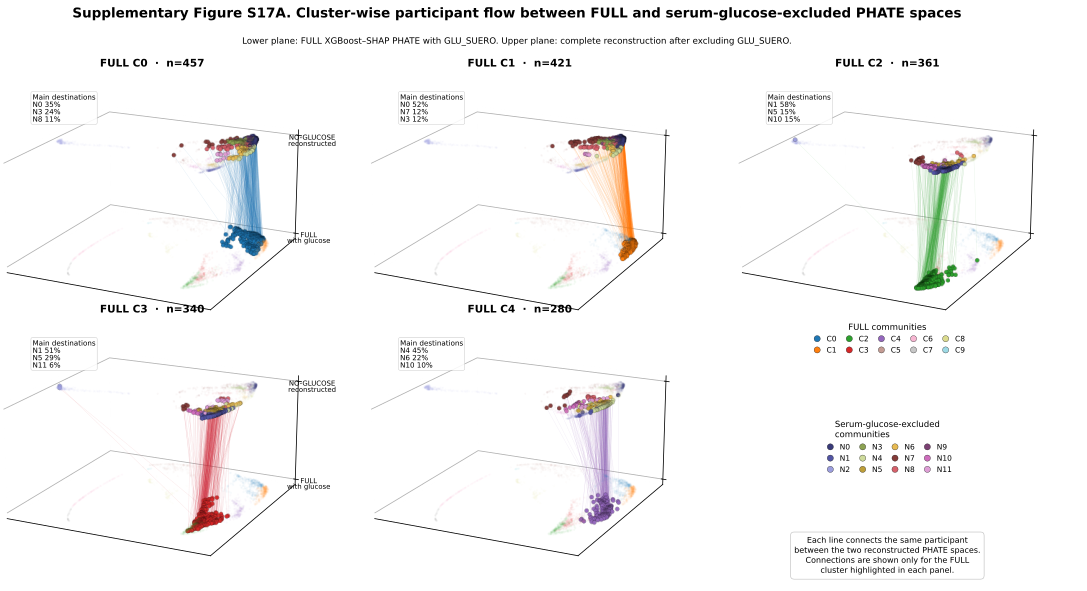

Saved: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/01_1_supplementary_stability_glucose_ablation/07_figures/S17_clusterwise_3D_PHATE_flow/S17A_clusterwise_3D_PHATE_flow_C0_C4


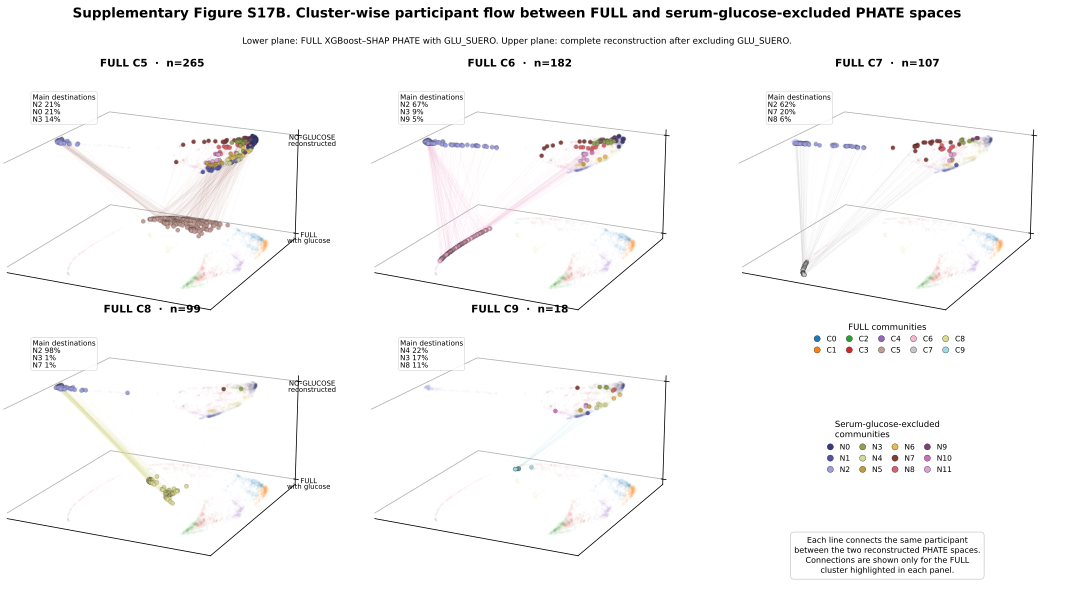

Saved: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/01_1_supplementary_stability_glucose_ablation/07_figures/S17_clusterwise_3D_PHATE_flow/S17B_clusterwise_3D_PHATE_flow_C5_C9

Completed compact S17 figure generation.
Output directory:
/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/01_1_supplementary_stability_glucose_ablation/07_figures/S17_clusterwise_3D_PHATE_flow


In [26]:
# ============================================================
# SUPPLEMENTARY FIGURE S17A–S17B
# Compact cluster-wise 3D participant flow between:
#   1) FULL PHATE, including serum glucose
#   2) Serum-glucose-excluded PHATE reconstruction
#
# - Matplotlib static figure suitable for PDF.
# - All participants are displayed in both PHATE layers.
# - Each panel draws connections only for one FULL cluster.
# - FULL points use FULL community colors.
# - Upper-layer points use NO-GLUCOSE community colors.
# - Two compact plates are generated:
#       S17A: C0–C4
#       S17B: C5–C9
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
from scipy.linalg import orthogonal_procrustes
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# ============================================================
# 1. CONFIGURATION
# ============================================================

PHATE_X = "UMAP_GRAPH_PHATE_1"
PHATE_Y = "UMAP_GRAPH_PHATE_2"
CLUSTER_COLUMN = "Cluster_SHAP"

PUBLICATION_DPI_LOCAL = (
    PUBLICATION_DPI
    if "PUBLICATION_DPI" in globals()
    else 300
)

# Figure output directory
if "DIRS" in globals() and "figures" in DIRS:
    BASE_FIGURE_DIR = Path(DIRS["figures"])
else:
    BASE_FIGURE_DIR = Path("./figures")

CLUSTER_FLOW_DIR = (
    BASE_FIGURE_DIR
    / "S17_clusterwise_3D_PHATE_flow"
)
CLUSTER_FLOW_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Appearance
BACKGROUND_POINT_SIZE = 4.2
BACKGROUND_ALPHA = 0.040

HIGHLIGHT_POINT_SIZE = 16
HIGHLIGHT_ALPHA = 0.97

CONNECTION_LINEWIDTH = 0.36
CONNECTION_ALPHA = 0.125

# Compact GridSpec spacing
GRID_WSPACE = -0.045
GRID_HSPACE = -0.085

# Shared 3D view
VIEW_ELEVATION = 18
VIEW_AZIMUTH = -64


# ============================================================
# 2. INPUT VALIDATION
# ============================================================

required_objects = [
    "full_representation",
    "no_glucose_representation",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "Required notebook objects are missing: "
        + ", ".join(missing_objects)
    )

required_columns = [
    PHATE_X,
    PHATE_Y,
    CLUSTER_COLUMN,
]

for table_name, table in [
    ("full_representation", full_representation),
    (
        "no_glucose_representation",
        no_glucose_representation,
    ),
]:
    missing_columns = [
        column
        for column in required_columns
        if column not in table.columns
    ]

    if missing_columns:
        raise KeyError(
            f"{table_name} is missing columns: "
            + ", ".join(missing_columns)
        )

if len(full_representation) != len(
    no_glucose_representation
):
    raise ValueError(
        "FULL and NO-GLUCOSE representations do not "
        "contain the same number of participants."
    )


# ============================================================
# 3. EXTRACT PHATE COORDINATES AND CLUSTER LABELS
# ============================================================

full_xy = (
    full_representation[
        [PHATE_X, PHATE_Y]
    ]
    .to_numpy(dtype=float)
)

no_glucose_xy = (
    no_glucose_representation[
        [PHATE_X, PHATE_Y]
    ]
    .to_numpy(dtype=float)
)

full_labels = (
    full_representation[CLUSTER_COLUMN]
    .to_numpy(dtype=int)
)

no_glucose_labels = (
    no_glucose_representation[CLUSTER_COLUMN]
    .to_numpy(dtype=int)
)

n_participants = len(full_xy)

full_clusters = sorted(
    np.unique(full_labels).tolist()
)

no_glucose_clusters = sorted(
    np.unique(no_glucose_labels).tolist()
)

print(
    f"Participants: {n_participants:,}"
)
print(
    "FULL clusters:",
    full_clusters,
)
print(
    "NO-GLUCOSE clusters:",
    no_glucose_clusters,
)


# ============================================================
# 4. ALIGN NO-GLUCOSE PHATE TO FULL PHATE
# ============================================================

def align_embedding_to_reference(
    reference_xy,
    target_xy,
):
    """
    Align a target 2D embedding to a reference embedding using
    centered and scaled orthogonal Procrustes alignment.

    This transformation is used only for visualization.
    It does not modify clustering labels or clustering metrics.
    """
    reference = np.asarray(
        reference_xy,
        dtype=float,
    )
    target = np.asarray(
        target_xy,
        dtype=float,
    )

    reference_mean = reference.mean(
        axis=0,
        keepdims=True,
    )
    target_mean = target.mean(
        axis=0,
        keepdims=True,
    )

    reference_centered = (
        reference - reference_mean
    )
    target_centered = (
        target - target_mean
    )

    reference_scale = np.sqrt(
        np.sum(reference_centered**2)
    )
    target_scale = np.sqrt(
        np.sum(target_centered**2)
    )

    if reference_scale == 0:
        raise ValueError(
            "The FULL PHATE embedding has zero variance."
        )

    if target_scale == 0:
        raise ValueError(
            "The NO-GLUCOSE PHATE embedding has "
            "zero variance."
        )

    reference_standardized = (
        reference_centered / reference_scale
    )
    target_standardized = (
        target_centered / target_scale
    )

    rotation_matrix, _ = (
        orthogonal_procrustes(
            target_standardized,
            reference_standardized,
        )
    )

    target_aligned = (
        target_standardized
        @ rotation_matrix
    )

    target_aligned = (
        target_aligned * reference_scale
        + reference_mean
    )

    return target_aligned


no_glucose_xy_aligned = (
    align_embedding_to_reference(
        reference_xy=full_xy,
        target_xy=no_glucose_xy,
    )
)


# ============================================================
# 5. SHARED AXIS LIMITS
# ============================================================

all_xy = np.vstack(
    [
        full_xy,
        no_glucose_xy_aligned,
    ]
)

xy_minimum = all_xy.min(axis=0)
xy_maximum = all_xy.max(axis=0)

x_range = (
    xy_maximum[0]
    - xy_minimum[0]
)
y_range = (
    xy_maximum[1]
    - xy_minimum[1]
)

if x_range == 0:
    x_range = 1.0

if y_range == 0:
    y_range = 1.0

x_padding = 0.035 * x_range
y_padding = 0.035 * y_range

x_limits = (
    xy_minimum[0] - x_padding,
    xy_maximum[0] + x_padding,
)

y_limits = (
    xy_minimum[1] - y_padding,
    xy_maximum[1] + y_padding,
)

z_full = np.zeros(
    n_participants,
    dtype=float,
)

z_no_glucose = np.ones(
    n_participants,
    dtype=float,
)


# ============================================================
# 6. COLOR MAPS
# ============================================================

full_colormap = plt.get_cmap(
    "tab20",
    max(len(full_clusters), 1),
)

no_glucose_colormap = plt.get_cmap(
    "tab20b",
    max(len(no_glucose_clusters), 1),
)

full_color_map = {
    cluster: full_colormap(position)
    for position, cluster
    in enumerate(full_clusters)
}

no_glucose_color_map = {
    cluster: no_glucose_colormap(position)
    for position, cluster
    in enumerate(no_glucose_clusters)
}

full_point_colors = [
    full_color_map[int(cluster)]
    for cluster in full_labels
]

no_glucose_point_colors = [
    no_glucose_color_map[int(cluster)]
    for cluster in no_glucose_labels
]


# ============================================================
# 7. HELPER FUNCTIONS
# ============================================================

def color_with_alpha(
    color,
    alpha,
):
    """
    Return an RGBA tuple with a specified transparency.
    """
    red, green, blue, _ = (
        mcolors.to_rgba(color)
    )

    return (
        red,
        green,
        blue,
        alpha,
    )


def compact_destination_text(
    full_cluster_mask,
    destination_labels,
    top_n=3,
):
    """
    Summarize the main NO-GLUCOSE destinations for one
    FULL cluster using multiple compact lines.
    """
    destination_distribution = (
        pd.Series(
            destination_labels[
                full_cluster_mask
            ]
        )
        .value_counts(normalize=True)
        .sort_values(ascending=False)
        .head(top_n)
    )

    if destination_distribution.empty:
        return "No destinations"

    return "\n".join(
        (
            f"N{int(destination_cluster)} "
            f"{proportion:.0%}"
        )
        for destination_cluster, proportion
        in destination_distribution.items()
    )


def save_static_figure_bundle(
    figure,
    output_base,
    dpi=300,
):
    """
    Save the figure as PNG, PDF and SVG.

    If the notebook already contains save_figure_bundle(),
    that function is attempted first.
    """
    output_base = Path(output_base)
    output_base.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    existing_save_function_used = False

    if "save_figure_bundle" in globals():
        try:
            save_figure_bundle(
                figure,
                output_base,
                dpi=dpi,
            )
            existing_save_function_used = True

        except Exception as error:
            print(
                "Existing save_figure_bundle() failed. "
                "Using direct Matplotlib export instead."
            )
            print(
                "Reason:",
                error,
            )

    if not existing_save_function_used:
        figure.savefig(
            str(output_base) + ".png",
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0.03,
        )

        figure.savefig(
            str(output_base) + ".pdf",
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0.03,
        )

        figure.savefig(
            str(output_base) + ".svg",
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0.03,
        )


def style_compact_3d_axis(
    axis,
    panel_column,
):
    """
    Apply compact publication formatting to one 3D panel.
    """
    axis.set_xlim(
        *x_limits
    )
    axis.set_ylim(
        *y_limits
    )
    axis.set_zlim(
        -0.055,
        1.055,
    )

    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_zticks(
        [0, 1]
    )

    # Layer labels are shown only in the first column.
    if panel_column == 0:
        axis.set_zticklabels(
            [
                "FULL\nwith glucose",
                "NO-GLUCOSE\nreconstructed",
            ],
            fontsize=6.9,
            linespacing=0.90,
        )
        axis.tick_params(
            axis="z",
            pad=-1,
        )
    else:
        axis.set_zticklabels([])

    axis.set_xlabel("")
    axis.set_ylabel("")
    axis.set_zlabel("")

    axis.view_init(
        elev=VIEW_ELEVATION,
        azim=VIEW_AZIMUTH,
    )

    # Enlarge the 3D object inside its subplot cell.
    try:
        axis.set_box_aspect(
            (
                1.0,
                1.0,
                0.54,
            ),
            zoom=1.19,
        )
    except TypeError:
        axis.set_box_aspect(
            (
                1.0,
                1.0,
                0.54,
            )
        )

    axis.set_anchor("C")

    try:
        axis.xaxis.pane.set_alpha(
            0.015
        )
        axis.yaxis.pane.set_alpha(
            0.015
        )
        axis.zaxis.pane.set_alpha(
            0.015
        )
    except Exception:
        pass

    axis.grid(
        True,
        alpha=0.065,
    )


def create_legend_information_panel(
    axis,
    clusters_on_plate,
):
    """
    Use the sixth GridSpec cell for legends and a concise
    explanation instead of leaving an empty subplot.
    """
    axis.set_axis_off()

    full_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markersize=6.2,
            markerfacecolor=(
                full_color_map[cluster]
            ),
            markeredgecolor="black",
            markeredgewidth=0.3,
            label=f"C{cluster}",
        )
        for cluster in full_clusters
    ]

    no_glucose_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markersize=6.2,
            markerfacecolor=(
                no_glucose_color_map[cluster]
            ),
            markeredgecolor="black",
            markeredgewidth=0.3,
            label=f"N{cluster}",
        )
        for cluster in no_glucose_clusters
    ]

    full_legend = axis.legend(
        handles=full_handles,
        loc="upper center",
        bbox_to_anchor=(
            0.50,
            0.98,
        ),
        ncol=5,
        frameon=False,
        title="FULL communities",
        fontsize=7.5,
        title_fontsize=8.5,
        columnspacing=0.70,
        handletextpad=0.25,
        borderaxespad=0,
    )

    axis.add_artist(
        full_legend
    )

    axis.legend(
        handles=no_glucose_handles,
        loc="center",
        bbox_to_anchor=(
            0.50,
            0.51,
        ),
        ncol=4,
        frameon=False,
        title=(
            "Serum-glucose-excluded\n"
            "communities"
        ),
        fontsize=7.5,
        title_fontsize=8.5,
        columnspacing=0.68,
        handletextpad=0.25,
        borderaxespad=0,
    )

    axis.text(
        0.50,
        0.105,
        (
            "Each line connects the same participant\n"
            "between the two reconstructed PHATE spaces.\n"
            "Connections are shown only for the FULL\n"
            "cluster highlighted in each panel."
        ),
        transform=axis.transAxes,
        ha="center",
        va="center",
        fontsize=8.0,
        linespacing=1.25,
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "white",
            "edgecolor": "0.72",
            "linewidth": 0.6,
            "alpha": 0.92,
        },
    )


# ============================================================
# 8. COMPACT PLATE GENERATOR
# ============================================================

def make_compact_cluster_plate(
    clusters_to_plot,
    plate_name,
    plate_title,
):
    """
    Generate one compact 2 × 3 supplementary plate.

    Five cells contain cluster-specific 3D plots.
    The sixth cell contains legends and explanatory text.
    """
    clusters_to_plot = list(
        clusters_to_plot
    )

    if len(clusters_to_plot) > 5:
        raise ValueError(
            "Each plate can contain a maximum "
            "of five cluster panels."
        )

    figure = plt.figure(
        figsize=(15.8, 8.35),
    )

    grid = figure.add_gridspec(
        nrows=2,
        ncols=3,
        left=0.010,
        right=0.995,
        bottom=0.018,
        top=0.875,
        wspace=GRID_WSPACE,
        hspace=GRID_HSPACE,
    )

    for panel_index, cluster in enumerate(
        clusters_to_plot
    ):
        panel_row = (
            panel_index // 3
        )
        panel_column = (
            panel_index % 3
        )

        axis = figure.add_subplot(
            grid[
                panel_row,
                panel_column,
            ],
            projection="3d",
        )

        cluster_mask = (
            full_labels == cluster
        )

        participant_indices = np.flatnonzero(
            cluster_mask
        )

        # ----------------------------------------------------
        # Background: all participants in FULL PHATE
        # ----------------------------------------------------
        axis.scatter(
            full_xy[:, 0],
            full_xy[:, 1],
            z_full,
            c=full_point_colors,
            s=BACKGROUND_POINT_SIZE,
            alpha=BACKGROUND_ALPHA,
            linewidths=0,
            depthshade=False,
            rasterized=True,
            zorder=1,
        )

        # ----------------------------------------------------
        # Background: all participants in NO-GLUCOSE PHATE
        # ----------------------------------------------------
        axis.scatter(
            no_glucose_xy_aligned[:, 0],
            no_glucose_xy_aligned[:, 1],
            z_no_glucose,
            c=no_glucose_point_colors,
            s=BACKGROUND_POINT_SIZE,
            alpha=BACKGROUND_ALPHA,
            linewidths=0,
            depthshade=False,
            rasterized=True,
            zorder=1,
        )

        # ----------------------------------------------------
        # Participant connections for the current FULL cluster
        # ----------------------------------------------------
        connection_color = color_with_alpha(
            full_color_map[cluster],
            CONNECTION_ALPHA,
        )

        for participant_index in participant_indices:
            axis.plot(
                [
                    full_xy[
                        participant_index,
                        0,
                    ],
                    no_glucose_xy_aligned[
                        participant_index,
                        0,
                    ],
                ],
                [
                    full_xy[
                        participant_index,
                        1,
                    ],
                    no_glucose_xy_aligned[
                        participant_index,
                        1,
                    ],
                ],
                [0, 1],
                color=connection_color,
                linewidth=CONNECTION_LINEWIDTH,
                alpha=CONNECTION_ALPHA,
                solid_capstyle="round",
                zorder=2,
            )

        # ----------------------------------------------------
        # Highlight current FULL cluster in lower PHATE
        # ----------------------------------------------------
        axis.scatter(
            full_xy[
                participant_indices,
                0,
            ],
            full_xy[
                participant_indices,
                1,
            ],
            z_full[
                participant_indices
            ],
            c=[
                full_color_map[cluster]
            ]
            * len(participant_indices),
            s=HIGHLIGHT_POINT_SIZE,
            alpha=HIGHLIGHT_ALPHA,
            linewidths=0.16,
            edgecolors="black",
            depthshade=False,
            rasterized=True,
            zorder=4,
        )

        # ----------------------------------------------------
        # Same participants in upper PHATE, colored according
        # to their NO-GLUCOSE destination communities
        # ----------------------------------------------------
        destination_colors = [
            no_glucose_color_map[
                int(destination_cluster)
            ]
            for destination_cluster
            in no_glucose_labels[
                participant_indices
            ]
        ]

        axis.scatter(
            no_glucose_xy_aligned[
                participant_indices,
                0,
            ],
            no_glucose_xy_aligned[
                participant_indices,
                1,
            ],
            z_no_glucose[
                participant_indices
            ],
            c=destination_colors,
            s=HIGHLIGHT_POINT_SIZE,
            alpha=HIGHLIGHT_ALPHA,
            linewidths=0.16,
            edgecolors="black",
            depthshade=False,
            rasterized=True,
            zorder=5,
        )

        # ----------------------------------------------------
        # Short title
        # ----------------------------------------------------
        axis.set_title(
            (
                f"FULL C{cluster}  ·  "
                f"n={cluster_mask.sum():,}"
            ),
            fontsize=10.5,
            fontweight="bold",
            pad=-2,
        )

        # ----------------------------------------------------
        # Compact destination box inside the panel
        # ----------------------------------------------------
        destination_text = (
            compact_destination_text(
                full_cluster_mask=cluster_mask,
                destination_labels=(
                    no_glucose_labels
                ),
                top_n=3,
            )
        )

        axis.text2D(
            0.055,
            0.910,
            (
                "Main destinations\n"
                + destination_text
            ),
            transform=axis.transAxes,
            ha="left",
            va="top",
            fontsize=7.15,
            linespacing=1.03,
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": "white",
                "edgecolor": "0.72",
                "linewidth": 0.42,
                "alpha": 0.87,
            },
            zorder=20,
        )

        style_compact_3d_axis(
            axis=axis,
            panel_column=panel_column,
        )

    # --------------------------------------------------------
    # Sixth cell: legends and figure explanation
    # --------------------------------------------------------
    information_axis = (
        figure.add_subplot(
            grid[1, 2]
        )
    )

    create_legend_information_panel(
        axis=information_axis,
        clusters_on_plate=clusters_to_plot,
    )

    # --------------------------------------------------------
    # Figure title and concise methodological subtitle
    # --------------------------------------------------------
    figure.suptitle(
        plate_title,
        fontsize=13.5,
        fontweight="bold",
        y=0.978,
    )

    figure.text(
        0.50,
        0.921,
        (
            "Lower plane: FULL XGBoost–SHAP PHATE "
            "with GLU_SUERO. Upper plane: complete "
            "reconstruction after excluding GLU_SUERO."
        ),
        ha="center",
        va="center",
        fontsize=8.7,
    )

    # Do not use tight_layout() or constrained_layout.
    display(
        figure
    )

    output_base = (
        CLUSTER_FLOW_DIR
        / plate_name
    )

    save_static_figure_bundle(
        figure=figure,
        output_base=output_base,
        dpi=PUBLICATION_DPI_LOCAL,
    )

    plt.close(
        figure
    )

    print(
        "Saved:",
        output_base,
    )


# ============================================================
# 9. GENERATE SUPPLEMENTARY FIGURES
# ============================================================

if len(full_clusters) < 10:
    print(
        "Warning: fewer than 10 FULL clusters were detected. "
        "The available clusters will still be plotted."
    )

first_plate_clusters = (
    full_clusters[:5]
)

second_plate_clusters = (
    full_clusters[5:10]
)

make_compact_cluster_plate(
    clusters_to_plot=first_plate_clusters,
    plate_name=(
        "S17A_clusterwise_3D_PHATE_flow_C0_C4"
    ),
    plate_title=(
        "Supplementary Figure S17A. "
        "Cluster-wise participant flow between FULL and "
        "serum-glucose-excluded PHATE spaces"
    ),
)

if second_plate_clusters:
    make_compact_cluster_plate(
        clusters_to_plot=second_plate_clusters,
        plate_name=(
            "S17B_clusterwise_3D_PHATE_flow_C5_C9"
        ),
        plate_title=(
            "Supplementary Figure S17B. "
            "Cluster-wise participant flow between FULL and "
            "serum-glucose-excluded PHATE spaces"
        ),
    )

print()
print(
    "Completed compact S17 figure generation."
)
print(
    "Output directory:"
)
print(
    CLUSTER_FLOW_DIR
)